In [1]:
import layers
import modules
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.signal import resample_poly
from scipy.signal import butter, sosfiltfilt
from pathlib import Path
from sklearn.model_selection import train_test_split
import os
import json
import pandas as pd
from tensorflow.keras.callbacks import ModelCheckpoint

from AF_metrics_utils import *

In [3]:
def sos_bandpass(lowcut, highcut, fs, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    # output = sos for numerically stable; use zero-phase via sosfiltfilt
    return butter(order, [low, high], btype='bandpass', output='sos')

def ecg_bandpass_zero_phase(x, fs, lowcut=0.5, highcut=40.0, order=2):
    sos = sos_bandpass(lowcut, highcut, fs, order=order)
    # zero-phase (acausal) filtering for offline learning
    return sosfiltfilt(sos, x)

def butter_lowpass_sos(cutoff_hz: float, fs: float, order: int = 4):
    """
    A Butterworth low-pass in second-order sections (SOS) for doppler envelopes
    cutoff_hz : cutoff frequency in Hz
    fs_hz     : sampling rate in Hz
    order     : filter order
    """
    sos = butter(order, cutoff_hz, btype='low', fs=fs, output='sos')
    return sos

def smooth_doppler_envelope(env: np.ndarray, fs: float,
                            cutoff_hz: float = 10.0, order: int = 4) -> np.ndarray:
    # Zero-phase smoothing of a Doppler envelope.
    sos = butter_lowpass_sos(cutoff_hz, fs, order=order)
    return sosfiltfilt(sos, env)

def normalize_signal(signal):
    # Normalize the signal to the range [-1, 1]
    signal_min = np.min(signal)
    signal_max = np.max(signal)
    normalized_signal = 2 * (signal - signal_min) / (signal_max - signal_min) - 1
    return normalized_signal

def ECG_preprocess(ecg_signal, fs):
    """
    Apply ECG preprocessing functions to fetal and maternal ECG signals
    """
    filtered_ecg = DUS_filtering(ecg_signal, fs)
    normalized_ecg = normalize_signal(filtered_ecg)
    return normalized_ecg

In [3]:
FS_ECG_ORIG = 2048        # Hz
FS_TARGET   = 284         # Hz
WIN_SEC     = 3.75        # window length (s)
STEP_SEC    = 1.875       # 50 % overlap

UP, DOWN = FS_TARGET, FS_ECG_ORIG          # 71 / 512 after gcd

def load_record(rec_idx: int, env_dir, ecg_dir):
    """Load one record and return 284 Hz ECG + envelope arrays."""
    env  = sio.loadmat(env_dir / f"{rec_idx}_envelope.mat")["x_up"].squeeze()
    ecg  = sio.loadmat(ecg_dir / f"results01_{rec_idx}.mat")["fref1"].flatten()

    # zero-phase filtering
    ecg_smooth = ecg_bandpass_zero_phase(ecg, fs=2048, lowcut=0.5, highcut=40.0, order=2)
    env_smooth = smooth_doppler_envelope(env, fs=284, cutoff_hz=10.0, order=4)
    # Resample ECG sequence to 284Hz to match with Doppler
    ecg284 = resample_poly(ecg_smooth, UP, DOWN).astype(np.float32)
    env_smooth    = env_smooth.astype(np.float32)
    # Trim for minor difference
    L = min(len(ecg284), len(env))
    return ecg[:L], ecg_smooth[:L], ecg284[:L], env[:L], env_smooth[:L]

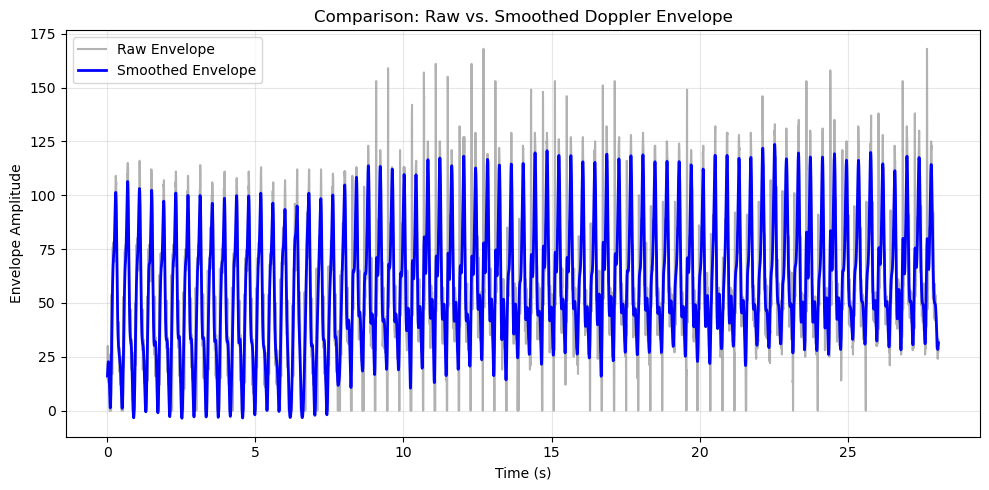

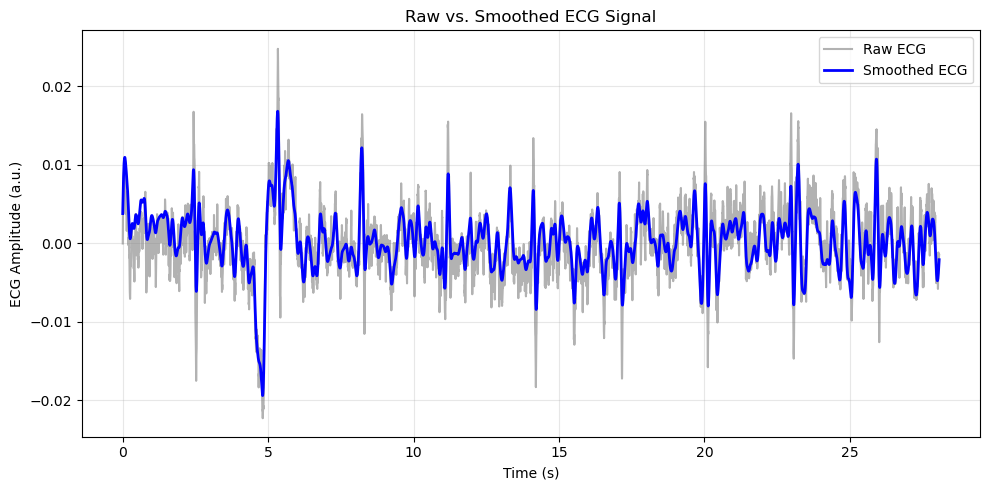

In [4]:
def plot_doppler(t, env_raw, env_smooth):
    plt.figure(figsize=(10, 5))
    plt.plot(t, env_raw, color='gray', alpha=0.6, label='Raw Envelope')
    plt.plot(t, env_smooth, color='blue', linewidth=2, label='Smoothed Envelope')
    plt.xlabel('Time (s)')
    plt.ylabel('Envelope Amplitude')
    plt.title('Comparison: Raw vs. Smoothed Doppler Envelope')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_ecg(t, ecg_raw, ecg_smooth):
    plt.figure(figsize=(10, 5))
    plt.plot(t, ecg_raw,   color='gray', alpha=0.6, label='Raw ECG')
    plt.plot(t, ecg_smooth, color='blue', linewidth=2, label='Smoothed ECG')
    plt.xlabel('Time (s)')
    plt.ylabel('ECG Amplitude (a.u.)')
    plt.title('Raw vs. Smoothed ECG Signal')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

FS_ECG_ORIG = 2048        # Hz
FS_TARGET   = 284         # Hz

ecg_raw, ecg_sm, ecg284, env_raw, env_sm = load_record(1, Path("/home/tsu25/envelops"), Path("/labs/katebilab/NinFEA_Data/Processed_Data"))
t = np.arange(len(env_sm), dtype=np.float32) / FS_TARGET
plot_doppler(t, env_raw, env_sm)

t_ecg = np.arange(len(ecg_sm), dtype=np.float32) / FS_ECG_ORIG
plot_ecg(t, ecg_raw, ecg_sm)

In [4]:
meta_data = pd.read_csv("/home/tsu25/Fetal-Maternal-Cardiac-Coupling/Deep_Learning/meta_data.csv")
meta_data['patient_id'] = range(1, len(meta_data)+1)
meta_data['signal_ids'] = meta_data['signal_ids'].apply(json.loads)
df_map = meta_data[['patient_id', 'signal_ids']].copy()

In [5]:
# map record id to patient id as a dictionary
df_long = (
    df_map
    .explode("signal_ids", ignore_index=True)
    .rename(columns={"signal_ids": "record_id"})
)

if df_long["record_id"].isna().any():
    raise ValueError("Some rows have empty signal_ids; fill or drop before proceeding.")

dupes = df_long.duplicated(subset=["record_id"], keep=False)
if dupes.any():
    clash = df_long.loc[dupes].sort_values("record_id")
    raise ValueError(f"Duplicate record_id assigned to multiple patients:\n{clash}")

rec_to_patient = dict(zip(df_long["record_id"].astype(int), df_long["patient_id"]))
patient_to_risk = dict(zip(meta_data['patient_id'], meta_data['High-Risk Pregnancy']))

In [11]:
WIN = int(WIN_SEC  * FS_TARGET)      # 3.75 s × 284 Hz = 1065
STEP = int(STEP_SEC * FS_TARGET)     # 50 % overlap

X, Y, PATIENT_IDS, RISK_GROUPS = [], [], [], []
for rec in range(1, 61):                
    _, _, ecg284, _, env = load_record(rec,
                              Path("/home/tsu25/envelops"),
                              Path("/labs/katebilab/NinFEA_Data/Processed_Data"))
    for s in range(0, len(env) - WIN, STEP):
        ecg_win = ecg284[s:s+WIN].astype(np.float32, copy=False)
        env_win = env[s:s+WIN].astype(np.float32, copy=False)

        # ECG per-window normalization
        ecg_win = (ecg_win - ecg_win.mean()) / (ecg_win.std() + 1e-6)

        # Doppler per-window normalization
        env_min, env_ptp = env_win.min(), env_win.ptp()
        env_win = 2.0 * (env_win - env_min)/(env_ptp + 1e-6) - 1.0  # [-1, 1]

        X.append(ecg_win[:, None])    # add channel dim
        Y.append(env_win)             # (WIN,)  or  env_win[:, None]
        patient_id = rec_to_patient[rec]
        risk_group = patient_to_risk[patient_id]
        PATIENT_IDS.append(patient_id)
        RISK_GROUPS.append(risk_group)

X = np.asarray(X, dtype=np.float32)
Y = np.asarray(Y, dtype=np.float32)
PATIENT_IDS = np.asarray(PATIENT_IDS)
RISK_GROUPS = np.asarray(RISK_GROUPS)
print("Final shapes:", X.shape, Y.shape, "Unique patient records:", np.unique(PATIENT_IDS).size)

Final shapes: (885, 1065, 1) (885, 1065) Unique patient records: 39


In [ ]:
save_dir_data = './WaveNet_beat/data'
os.makedirs(save_dir_data, exist_ok=True)
np.save(os.path.join(save_dir_data, f'X.npy'), X)
np.save(os.path.join(save_dir_data, f'Y.npy'), Y)
np.save(os.path.join(save_dir_data, f'PATIENT_IDS.npy'), PATIENT_IDS)
np.save(os.path.join(save_dir_data, f'RISK_GROUPS.npy'), RISK_GROUPS)

In [ ]:
# ECG_train, ECG_test, ENV_train, ENV_test = train_test_split(
#     X, Y, test_size=0.2, random_state=0, shuffle=True
# )

### Single patient-level train/val split

In [8]:
train_idx = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/idx_train.npy')
val_idx = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/idx_val.npy')

In [9]:
tr_pats = set(PATIENT_IDS[train_idx])                                    
va_pats = set(PATIENT_IDS[val_idx])                                      
assert tr_pats.isdisjoint(va_pats), "Patient leakage between train/val!" 

fold_rows = []            
best_val_losses = []     

save_dir_model = './WaveNet_beat/models'
save_dir_loss  = './WaveNet_beat/logs'
save_dir_plots = './WaveNet_beat/plots'
os.makedirs(save_dir_model, exist_ok=True)
os.makedirs(save_dir_loss,  exist_ok=True)
os.makedirs(save_dir_plots, exist_ok=True)

n_epochs = 10
batch_size = 32

latent_dim = WIN
model = modules.WaveNet_v2(input_shape=(latent_dim, 1))
model.compile(optimizer="adam", loss="mae")

checkpoint_callback = ModelCheckpoint(
    filepath=os.path.join(save_dir_model, f'best_single_model.weights.h5'),
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

history = model.fit(
    X[train_idx], Y[train_idx],
    validation_data=(X[val_idx], Y[val_idx]),
    epochs=n_epochs,
    batch_size=batch_size,
    callbacks=[checkpoint_callback],
    verbose=1
)

val_losses = history.history.get('val_loss', [])
best_val = float(np.min(val_losses)) if len(val_losses) else float(model.evaluate(X[val_idx], Y[val_idx], verbose=0))
best_val_losses.append(best_val)

np.save(os.path.join(save_dir_loss, f'loss_split.npy'),     history.history['loss'])   
np.save(os.path.join(save_dir_loss, f'val_loss_split.npy'), val_losses)                
model.save_weights(os.path.join(save_dir_model, f'final_model.weights.h5'))
                    

train_patients = np.unique(PATIENT_IDS[train_idx])   
val_patients   = np.unique(PATIENT_IDS[val_idx])    

fold_rows.append({
    "split": "patient_split",                        
    "train_patients": train_patients.size,
    "val_patients":   val_patients.size,
    "train_segments": train_idx.size,
    "val_segments":   val_idx.size,
    "best_val_loss":  best_val
})

# Table(s)
df_split = pd.DataFrame(fold_rows)
print("\nSplit results:\n", df_split.to_string(index=False))

# qualitative plots on the validation set
if val_idx.size >= 4:
    #rng = np.random.default_rng(0)
    #rand_val_idx = rng.choice(val_idx, size=4, replace=False)
    #showcase_idx_file = os.path.join(save_dir_plots, "val_showcase_idx.npy")
    #np.save(showcase_idx_file, rand_val_idx)
    best_model = modules.WaveNet_v2(input_shape=(latent_dim, 1))
    best_model.compile(optimizer="adam", loss="mae")
    best_model.load_weights(os.path.join(save_dir_model, f'best_single_model.weights.h5'))

    rand_val_idx = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/WaveNet_beat/plots/val_showcase_idx.npy')
    selected_ecgs = X[rand_val_idx]
    selected_real_dopplers = Y[rand_val_idx]
    best_model_generated_dopplers = best_model.predict(selected_ecgs, verbose=0).squeeze(-1)
    final_model_generated_dopplers = model.predict(selected_ecgs, verbose=0).squeeze(-1)

    print('Generated vs. Actual for best val loss model saved:')
    modules.plot_ecg_doppler_pairs(selected_ecgs, selected_real_dopplers, best_model_generated_dopplers)
    print('Generated vs. Actual for final model saved:')
    modules.plot_ecg_doppler_pairs(selected_ecgs, selected_real_dopplers, final_model_generated_dopplers)

    #modules.plot_scalogram(selected_real_dopplers, generated_dopplers)

Model: "WaveNet_one_channel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fetal_ecg_to_doppl… │ (None, 1065, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1065, 64)  │      1,344 │ fetal_ecg_to_dop… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1065, 64)  │      1,344 │ fetal_ecg_to_dop… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1065, 64)  │          0 │ conv1d[0][0],     │
│                     │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1065, 64)  │        128 │ fetal_ecg_to_dop… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1065, 64)  │          0 │ multiply[0][0],   │
│                     │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1065, 64)  │     81,984 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 1065, 64)  │     81,984 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 1065, 64)  │          0 │ conv1d_4[0][0],   │
│ (Multiply)          │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 1065, 64)  │      4,160 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1065, 64)  │          0 │ multiply_1[0][0], │
│                     │                   │            │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 1065, 64)  │     81,984 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 1065, 64)  │     81,984 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 1065, 64)  │          0 │ conv1d_8[0][0],   │
│ (Multiply)          │                   │            │ conv1d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 1065, 64)  │      4,160 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1065, 64)  │          0 │ multiply_2[0][0], │
│                     │                   │            │ conv1d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 1065, 64)  │     81,984 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 1065, 64)  │     81,984 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 1065, 64)  │          0 │ conv1d_12[0][0],  │
│ (Multiply)          │                   │            │ conv1d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 1065, 64)  │      4,160 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 1065, 64)  │          0 │ multiply_3[0][0]

 Total params: 1,040,769 (3.97 MB)

 Trainable params: 1,040,769 (3.97 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
15/22 ━━━━━━━━━━━━━━━━━━━━ 1:13 11s/step - loss: 0.4381

KeyboardInterrupt: 

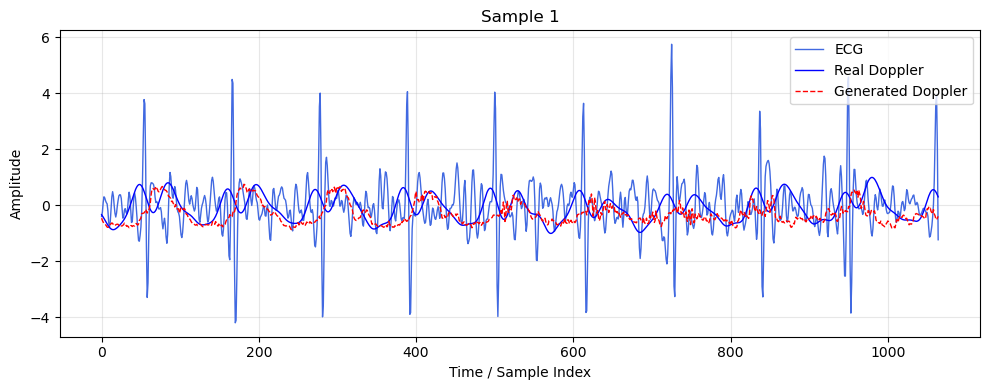

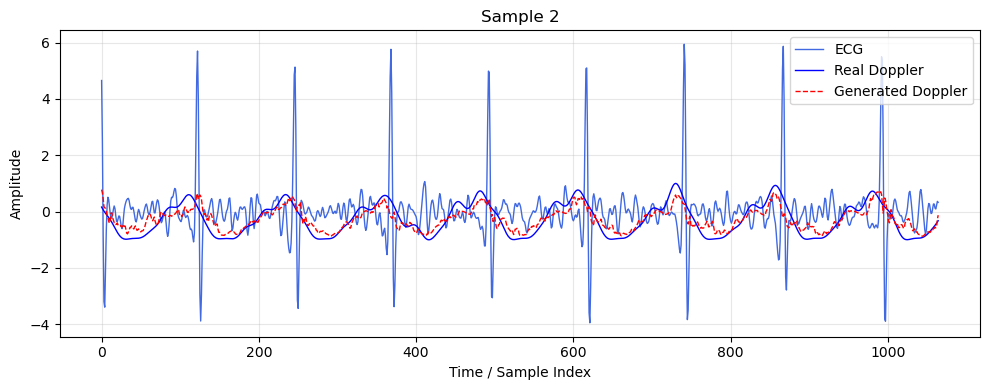

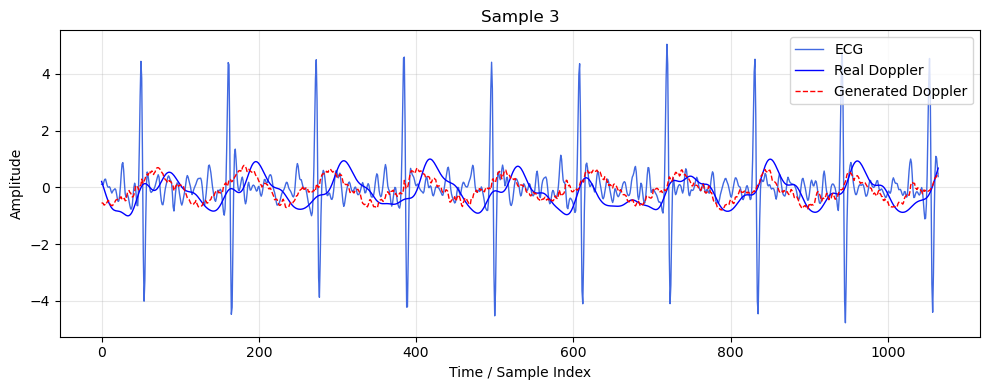

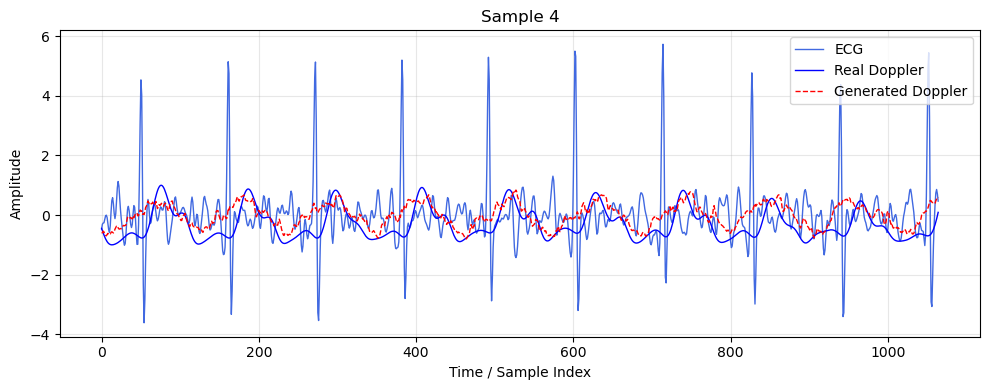

In [31]:
modules.plot_ecg_doppler_overlay(selected_ecgs, selected_real_dopplers, generated_dopplers)

### Model Training

In [ ]:
# Set latent dimension to window size for input
latent_dim = WIN
WaveNet = modules.WaveNet_v2(input_shape=(latent_dim, 1))
WaveNet.compile(optimizer="adam", loss="mae")

n_epochs = 30

history = WaveNet.fit(ECG_train,
                      ENV_train,
                      epochs=n_epochs,
                      batch_size=32,
                      validation_split=0.1)

save_dir_model = './WaveNet_beat/models'
save_dir_loss = './WaveNet_beat/logs'
save_dir_plots = './WaveNet_beat/plots'
os.makedirs(save_dir_model, exist_ok=True)
WaveNet.save(os.path.join(save_dir_model, 'model_v3.h5'))

os.makedirs(save_dir_loss, exist_ok=True)
np.save(os.path.join(save_dir_loss, 'loss_1.npy'), history.history['loss'])

os.makedirs(save_dir_plots, exist_ok=True)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.savefig('./WaveNet_beat/plots/loss_3.png')
plt.show()

# Show some random generated
# Randomly select 4 ECG samples and their corresponding real Doppler from the dataset
random_indices = np.random.choice(len(ECG_test), 4, replace=False)
selected_ecgs = ECG_test[random_indices]
selected_real_dopplers = ENV_test[random_indices]
# Generate Doppler using the model
generated_dopplers = WaveNet.predict(selected_ecgs).squeeze(-1)
# Plot the selected ECGs, real Dopplers, and their corresponding generated Doppler signals
modules.plot_ecg_doppler_pairs(selected_ecgs, selected_real_dopplers, generated_dopplers)
modules.plot_scalogram(selected_real_dopplers, generated_dopplers)

Model: "WaveNet_one_channel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fetal_ecg_to_doppl… │ (None, 1065, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1065, 64)  │      1,344 │ fetal_ecg_to_dop… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1065, 64)  │      1,344 │ fetal_ecg_to_dop… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1065, 64)  │          0 │ conv1d[0][0],     │
│                     │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1065, 64)  │        128 │ fetal_ecg_to_dop… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1065, 64)  │          0 │ multiply[0][0],   │
│                     │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1065, 64)  │     81,984 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 1065, 64)  │     81,984 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 1065, 64)  │          0 │ conv1d_4[0][0],   │
│ (Multiply)          │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 1065, 64)  │      4,160 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1065, 64)  │          0 │ multiply_1[0][0], │
│                     │                   │            │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 1065, 64)  │     81,984 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 1065, 64)  │     81,984 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 1065, 64)  │          0 │ conv1d_8[0][0],   │
│ (Multiply)          │                   │            │ conv1d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 1065, 64)  │      4,160 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1065, 64)  │          0 │ multiply_2[0][0], │
│                     │                   │            │ conv1d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 1065, 64)  │     81,984 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 1065, 64)  │     81,984 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 1065, 64)  │          0 │ conv1d_12[0][0],  │
│ (Multiply)          │                   │            │ conv1d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 1065, 64)  │      4,160 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 1065, 64)  │          0 │ multiply_3[0][0]

 Total params: 1,040,769 (3.97 MB)

 Trainable params: 1,040,769 (3.97 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - loss: 0.4398 - val_loss: 0.4209
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - loss: 0.4106 - val_loss: 0.4159
Epoch 3/30
18/20 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 0.4094

KeyboardInterrupt: 

### Evaluation archive

In [10]:
# ---------- helper that builds an Activation layer regardless of config -----
def _act_builder(act_fn):
    # Keras deserializer calls obj(**config); we pop unknown keys here
    return lambda **cfg: tf.keras.layers.Activation(
        act_fn,
        name=cfg.pop("name", None),           # keep layer name if present
        trainable=cfg.pop("trainable", True)  # default True
    )

custom_objects = {
    "Tanh":      _act_builder(tf.keras.activations.tanh),
    "Relu":      _act_builder(tf.keras.activations.relu),
    "Silu":      _act_builder(tf.keras.activations.silu),
    "Sigmoid":   _act_builder(tf.keras.activations.sigmoid),
    "Softmax":   _act_builder(tf.keras.activations.softmax),
    # LeakyReLU is already a dedicated layer class, expose it directly
    "LeakyRelu": lambda **cfg: tf.keras.layers.LeakyReLU(
        negative_slope=cfg.pop("alpha", 0.2),  # Keras uses `negative_slope`
        name=cfg.pop("name", None),
        **cfg                                    # trainable, dtype, etc.
    ),
}

In [ ]:
save_dir_model = './WaveNet_beat/models'
save_dir_loss  = './WaveNet_beat/logs'
save_dir_plots = './WaveNet_beat/plots'
save_dir_generated = './WaveNet_beat/generated_data' 
os.makedirs(save_dir_model, exist_ok=True)
os.makedirs(save_dir_loss,  exist_ok=True)
os.makedirs(save_dir_plots, exist_ok=True)
os.makedirs(save_dir_generated, exist_ok=True)

latent_dim = 1065

best_model = modules.WaveNet_v2(input_shape=(latent_dim, 1), filters=32, kernel_size=15, 
                   dilation_rates=[2**i for i in range(6)])
best_model.compile(optimizer="adam", loss="mae")
best_model.load_weights(os.path.join(save_dir_model, f'best_single_model.weights.h5'))

model = modules.WaveNet_v2(input_shape=(latent_dim, 1), filters=32, kernel_size=15, 
                   dilation_rates=[2**i for i in range(6)])
model.compile(optimizer="adam", loss="mae")
model.load_weights(os.path.join(save_dir_model, f'final_model.weights.h5'))

#rand_val_idx = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/WaveNet_beat/plots/val_showcase_idx.npy')
Y = np.load('/home/tsu25/ECG_PWD/single_channel/src/WaveNet_beat/data/Y.npy')
selected_ecgs = X[val_idx]
selected_real_dopplers = Y[val_idx]

best_model_generated_dopplers = best_model.predict(selected_ecgs, verbose=0).squeeze(-1)
final_model_generated_dopplers = model.predict(selected_ecgs, verbose=0).squeeze(-1)

np.save(os.path.join(save_dir_generated, 'best_one_ch_model_generated_dopplers.npy'), 
        best_model_generated_dopplers)
np.save(os.path.join(save_dir_generated, 'final_one_ch_model_generated_dopplers.npy'), 
        final_model_generated_dopplers)

Model: "WaveNet_one_channel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fetal_ecg_to_doppl… │ (None, 1065, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_104 (Conv1D) │ (None, 1065, 32)  │        512 │ fetal_ecg_to_dop… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_105 (Conv1D) │ (None, 1065, 32)  │        512 │ fetal_ecg_to_dop… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_24         │ (None, 1065, 32)  │          0 │ conv1d_104[0][0], │
│ (Multiply)          │                   │            │ conv1d_105[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_107 (Conv1D) │ (None, 1065, 32)  │         64 │ fetal_ecg_to_dop… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_28 (Add)        │ (None, 1065, 32)  │          0 │ multiply_24[0][0… │
│                     │                   │            │ conv1d_107[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_108 (Conv1D) │ (None, 1065, 32)  │     15,392 │ add_28[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_109 (Conv1D) │ (None, 1065, 32)  │     15,392 │ add_28[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_25         │ (None, 1065, 32)  │          0 │ conv1d_108[0][0], │
│ (Multiply)          │                   │            │ conv1d_109[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_111 (Conv1D) │ (None, 1065, 32)  │      1,056 │ add_28[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_29 (Add)        │ (None, 1065, 32)  │          0 │ multiply_25[0][0… │
│                     │                   │            │ conv1d_111[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_112 (Conv1D) │ (None, 1065, 32)  │     15,392 │ add_29[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_113 (Conv1D) │ (None, 1065, 32)  │     15,392 │ add_29[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_26         │ (None, 1065, 32)  │          0 │ conv1d_112[0][0], │
│ (Multiply)          │                   │            │ conv1d_113[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_115 (Conv1D) │ (None, 1065, 32)  │      1,056 │ add_29[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_30 (Add)        │ (None, 1065, 32)  │          0 │ multiply_26[0][0… │
│                     │                   │            │ conv1d_115[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_116 (Conv1D) │ (None, 1065, 32)  │     15,392 │ add_30[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_117 (Conv1D) │ (None, 1065, 32)  │     15,392 │ add_30[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_27         │ (None, 1065, 32)  │          0 │ conv1d_116[0][0], │
│ (Multiply)          │                   │            │ conv1d_117[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_119 (Conv1D) │ (None, 1065, 32)  │      1,056 │ add_30[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_31 (Add)        │ (None, 1065, 32)  │          0 │ multiply_27[0][0

 Total params: 166,657 (651.00 KB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 0 (0.00 B)

Model: "WaveNet_one_channel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fetal_ecg_to_doppl… │ (None, 1065, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_130 (Conv1D) │ (None, 1065, 32)  │        512 │ fetal_ecg_to_dop… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_131 (Conv1D) │ (None, 1065, 32)  │        512 │ fetal_ecg_to_dop… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_30         │ (None, 1065, 32)  │          0 │ conv1d_130[0][0], │
│ (Multiply)          │                   │            │ conv1d_131[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_133 (Conv1D) │ (None, 1065, 32)  │         64 │ fetal_ecg_to_dop… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_35 (Add)        │ (None, 1065, 32)  │          0 │ multiply_30[0][0… │
│                     │                   │            │ conv1d_133[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_134 (Conv1D) │ (None, 1065, 32)  │     15,392 │ add_35[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_135 (Conv1D) │ (None, 1065, 32)  │     15,392 │ add_35[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_31         │ (None, 1065, 32)  │          0 │ conv1d_134[0][0], │
│ (Multiply)          │                   │            │ conv1d_135[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_137 (Conv1D) │ (None, 1065, 32)  │      1,056 │ add_35[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_36 (Add)        │ (None, 1065, 32)  │          0 │ multiply_31[0][0… │
│                     │                   │            │ conv1d_137[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_138 (Conv1D) │ (None, 1065, 32)  │     15,392 │ add_36[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_139 (Conv1D) │ (None, 1065, 32)  │     15,392 │ add_36[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_32         │ (None, 1065, 32)  │          0 │ conv1d_138[0][0], │
│ (Multiply)          │                   │            │ conv1d_139[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_141 (Conv1D) │ (None, 1065, 32)  │      1,056 │ add_36[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_37 (Add)        │ (None, 1065, 32)  │          0 │ multiply_32[0][0… │
│                     │                   │            │ conv1d_141[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_142 (Conv1D) │ (None, 1065, 32)  │     15,392 │ add_37[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_143 (Conv1D) │ (None, 1065, 32)  │     15,392 │ add_37[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_33         │ (None, 1065, 32)  │          0 │ conv1d_142[0][0], │
│ (Multiply)          │                   │            │ conv1d_143[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_145 (Conv1D) │ (None, 1065, 32)  │      1,056 │ add_37[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_38 (Add)        │ (None, 1065, 32)  │          0 │ multiply_33[0][0

 Total params: 166,657 (651.00 KB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
save_dir_model = './WaveNet_beat/models'
save_dir_loss  = './WaveNet_beat/logs'
save_dir_plots = './WaveNet_beat/plots'
save_dir_generated = './WaveNet_beat/generated_data' 
os.makedirs(save_dir_model, exist_ok=True)
os.makedirs(save_dir_loss,  exist_ok=True)
os.makedirs(save_dir_plots, exist_ok=True)
os.makedirs(save_dir_generated, exist_ok=True)

latent_dim = 1065

best_model = modules.WaveNet_v2(input_shape=(latent_dim, 1), filters=32, kernel_size=15, 
                   dilation_rates=[2**i for i in range(6)])
best_model.compile(optimizer="adam", loss="mae")
best_model.load_weights(os.path.join(save_dir_model, f'best_single_model.weights.h5'))

model = modules.WaveNet_v2(input_shape=(latent_dim, 1), filters=32, kernel_size=15, 
                   dilation_rates=[2**i for i in range(6)])
model.compile(optimizer="adam", loss="mae")
model.load_weights(os.path.join(save_dir_model, f'final_model.weights.h5'))

#rand_val_idx = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/WaveNet_beat/plots/val_showcase_idx.npy')
Y = np.load('/home/tsu25/ECG_PWD/single_channel/src/WaveNet_beat/data/Y.npy')
selected_ecgs = X[val_idx]
selected_real_dopplers = Y[val_idx]

best_model_generated_dopplers = best_model.predict(selected_ecgs, verbose=0).squeeze(-1)
final_model_generated_dopplers = model.predict(selected_ecgs, verbose=0).squeeze(-1)

np.save(os.path.join(save_dir_generated, 'best_one_ch_model_generated_dopplers.npy'), 
        best_model_generated_dopplers)
np.save(os.path.join(save_dir_generated, 'final_one_ch_model_generated_dopplers.npy'), 
        final_model_generated_dopplers)

### Evaluation

In [19]:
train_idx = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/idx_train_risk.npy')
val_idx = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/idx_val_risk.npy')
RISK_GROUPS = np.load("/home/tsu25/ECG_PWD/single_channel/src/WaveNet_beat/data/RISK_GROUPS.npy")

# Load the generated data
#two_ch_generated = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/WaveNet_beat/generated_data/final_two_ch_model_generated_dopplers.npy')
#one_ch_generated = np.load('/home/tsu25/ECG_PWD/single_channel/src/WaveNet_beat/generated_data/final_one_ch_model_generated_dopplers.npy')
#comp_fusion = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/WaveNet_beat/generated_data/comp_model_dopplers.npy')
two_ch_generated = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/WaveNet_beat/generated_data/low_risk_fusion_model_final.npy')

Y = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/WaveNet_beat/data/Y.npy')
selected_real_dopplers = Y[val_idx]
real_dopplers = selected_real_dopplers

In [20]:
X = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/WaveNet_beat/data/X.npy')
selected_ecgs = X[val_idx]

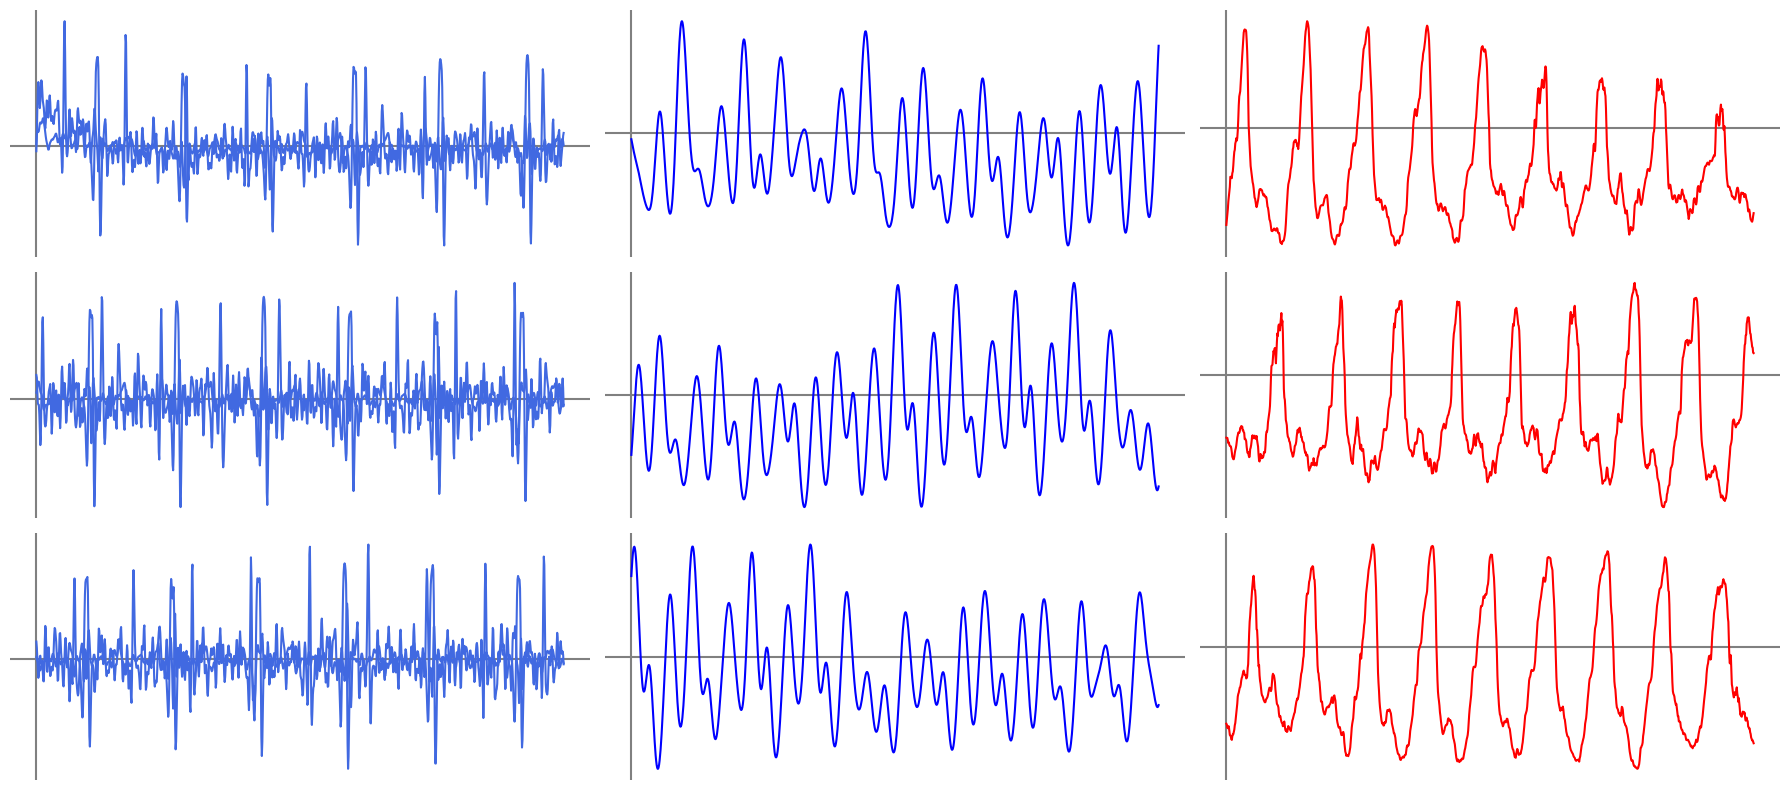

In [21]:
modules.plot_ecg_doppler_pairs(selected_ecgs[:3], selected_real_dopplers[:3], two_ch_generated[:3])

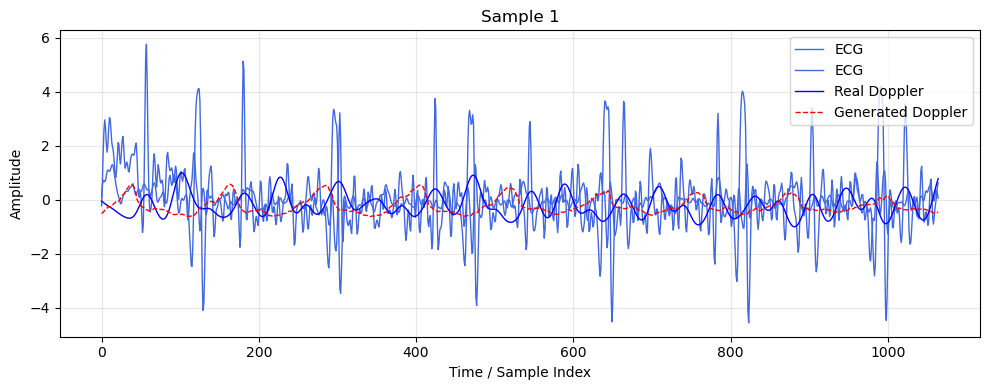

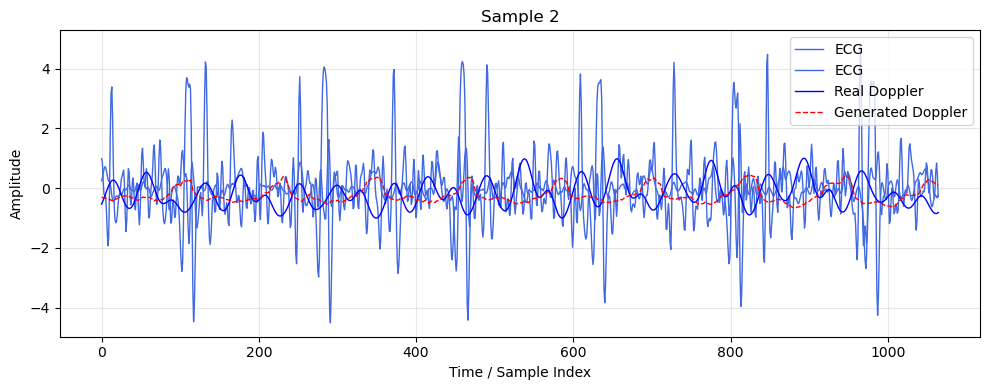

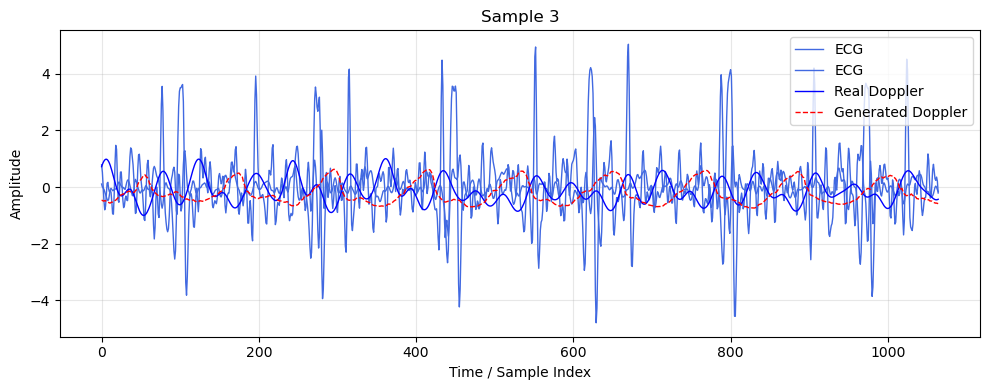

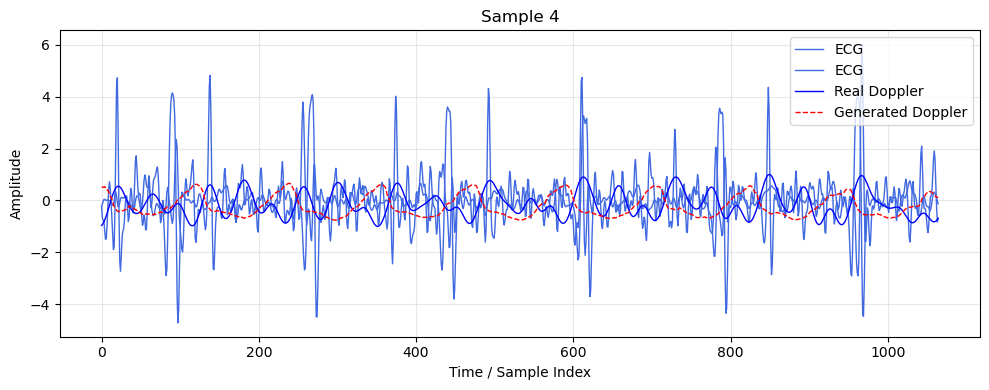

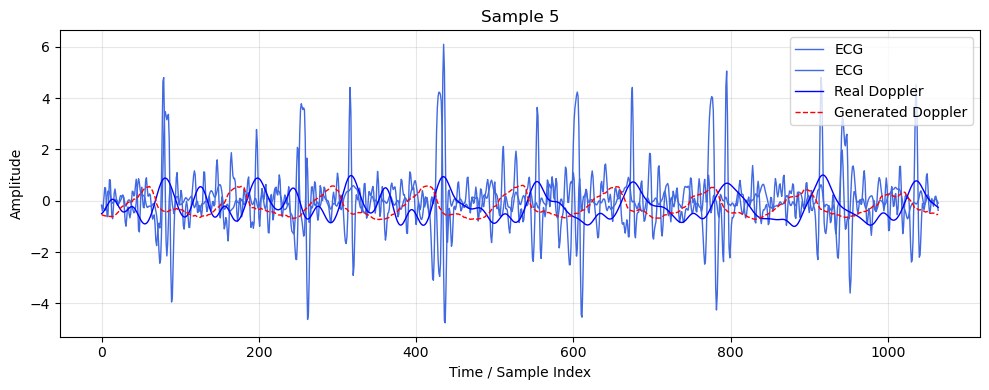

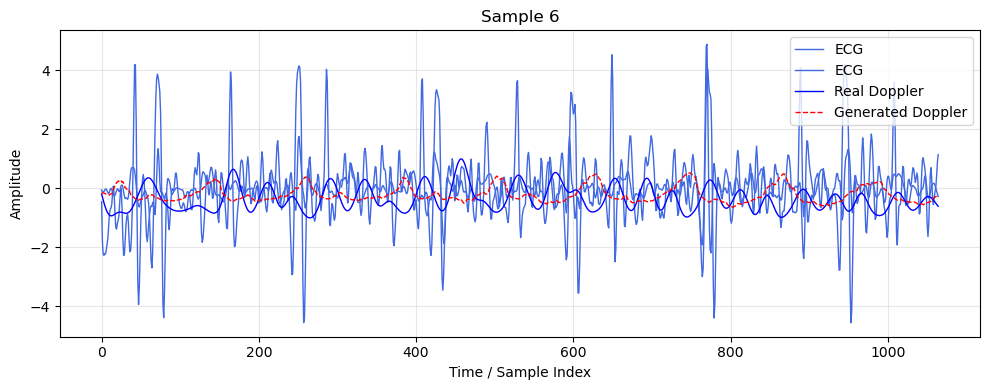

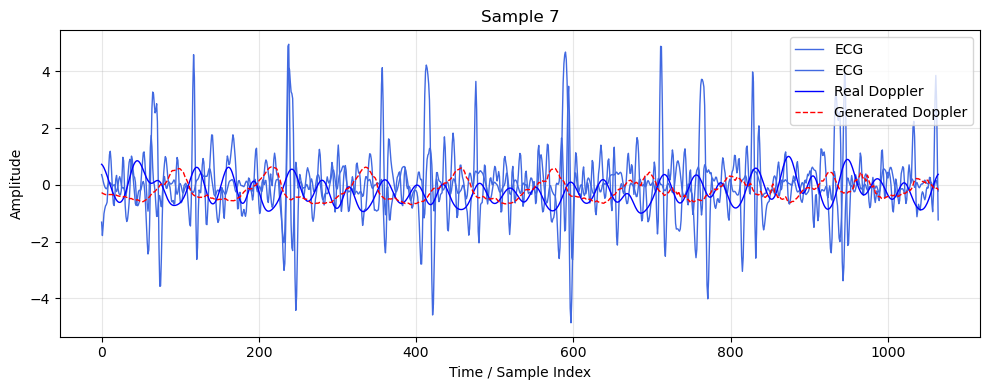

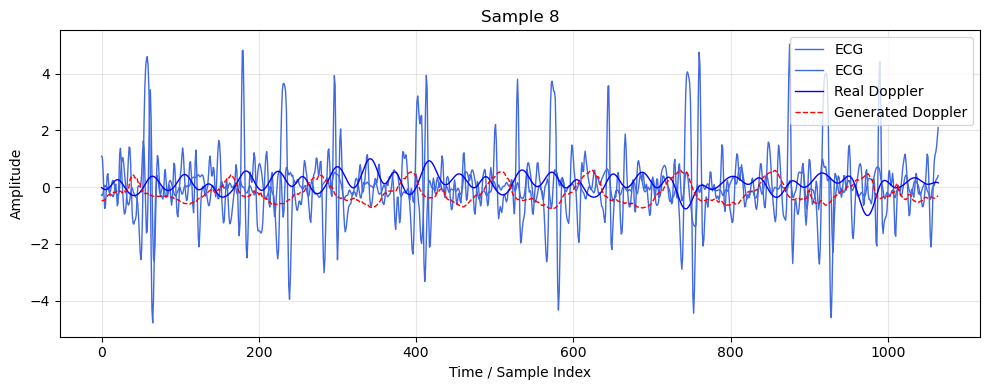

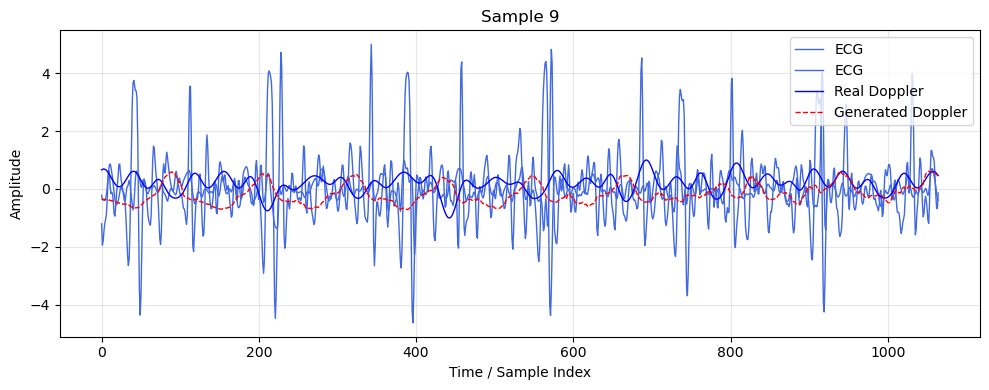

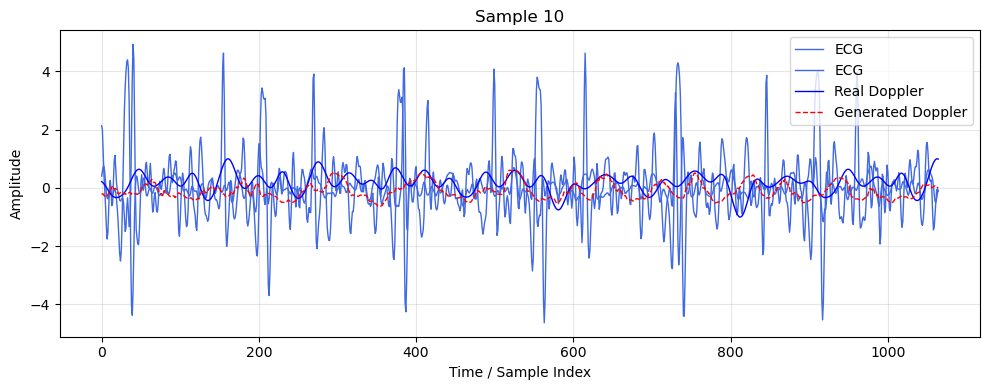

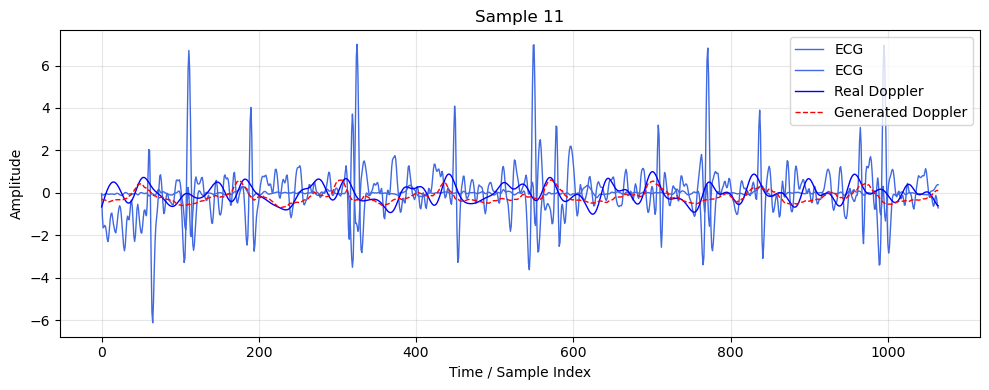

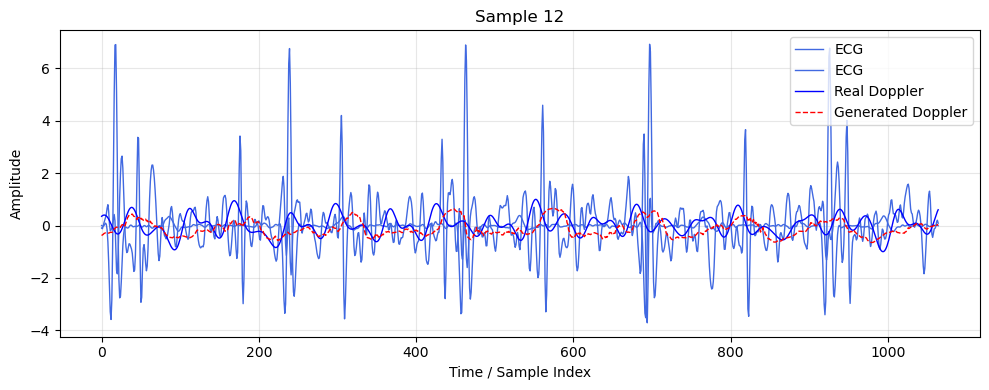

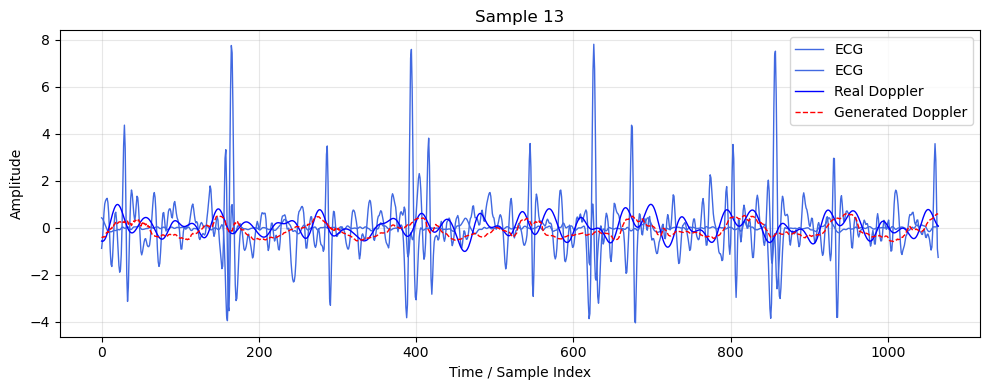

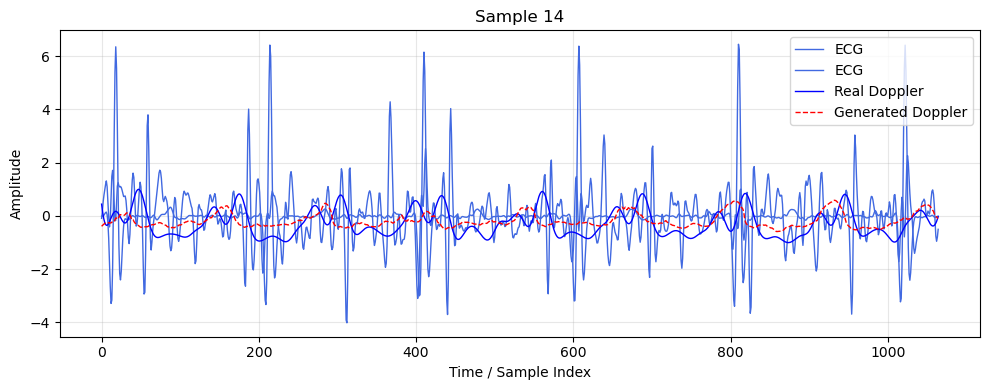

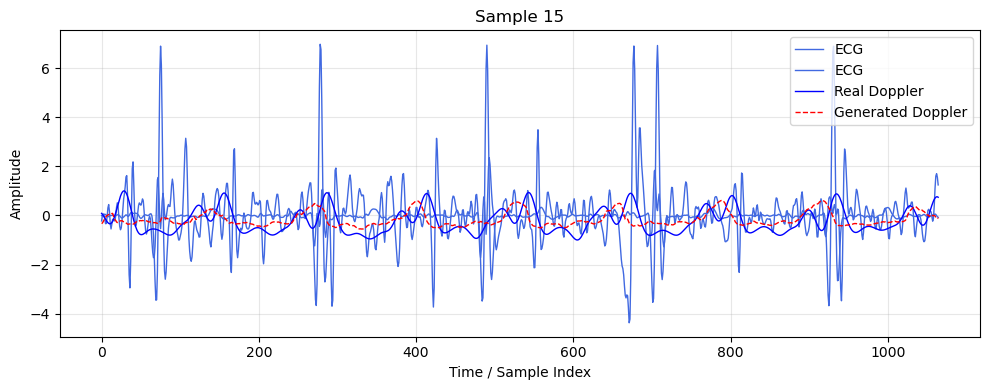

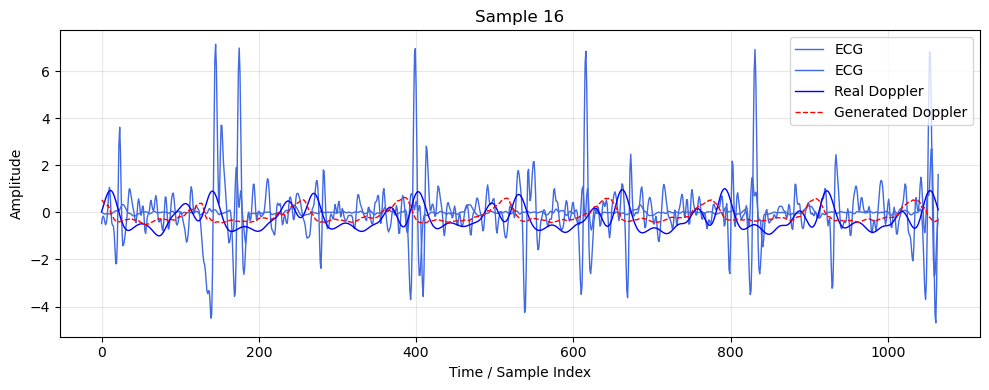

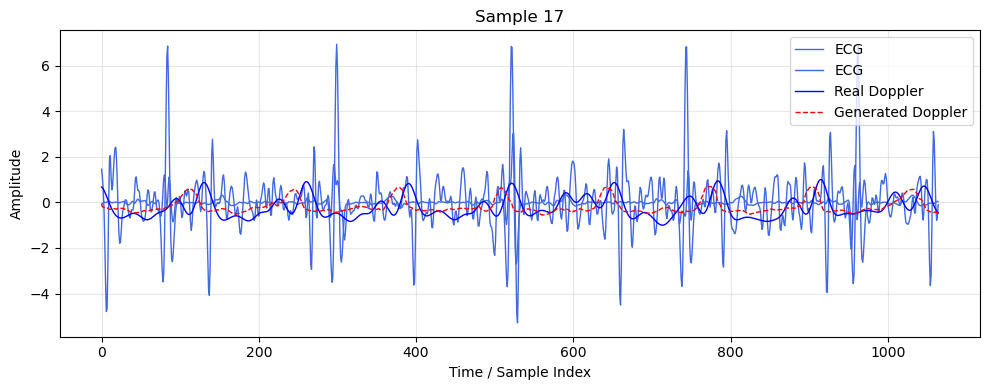

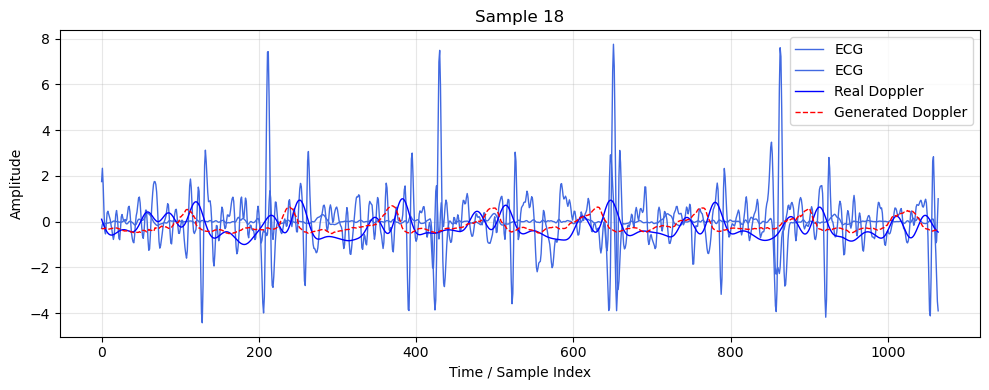

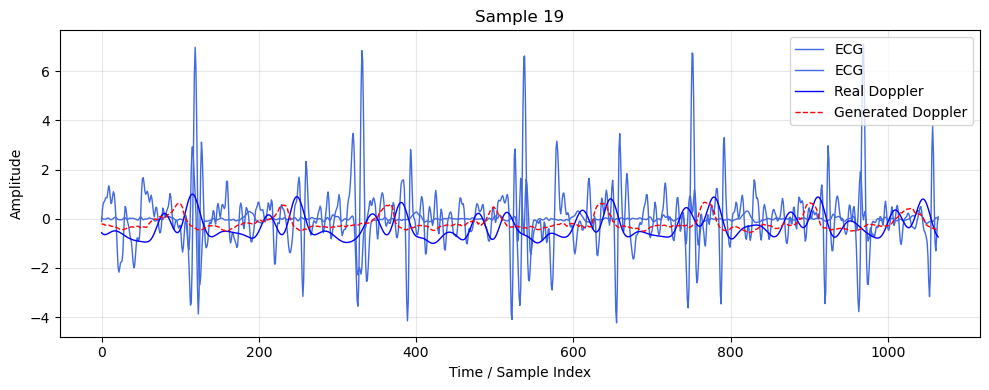

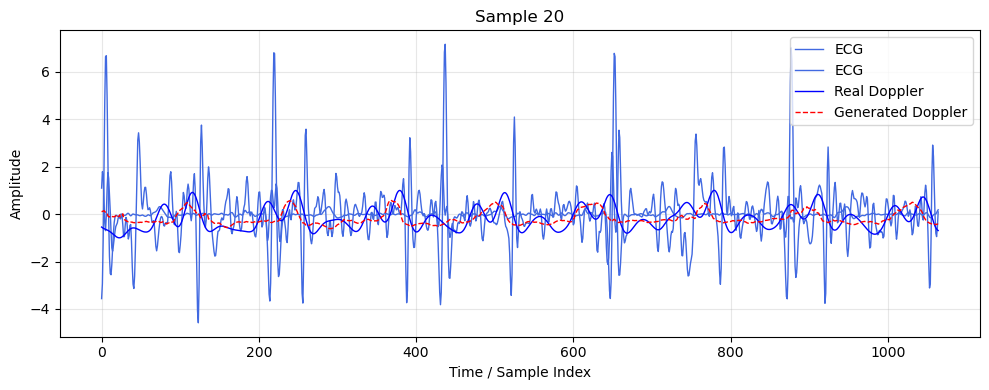

In [23]:
modules.plot_ecg_doppler_overlay(selected_ecgs[:20], selected_real_dopplers[:20], two_ch_generated[:20])

In [5]:
val_risk_groups = RISK_GROUPS[val_idx]
# Separate indices by risk group
high_risk_mask = val_risk_groups == 'yes'
low_risk_mask = val_risk_groups == 'no'

# Get predictions and ground truth for each group
high_risk_real = real_dopplers[high_risk_mask]
high_risk_two_ch = two_ch_generated[high_risk_mask]
#high_risk_one_ch = one_ch_generated[high_risk_mask]

low_risk_real = real_dopplers[low_risk_mask]
low_risk_two_ch = two_ch_generated[low_risk_mask]
#low_risk_one_ch = one_ch_generated[low_risk_mask]

# Now compute metrics separately for each group
print(f"High-risk samples: {high_risk_mask.sum()}")
print(f"Low-risk samples: {low_risk_mask.sum()}")

High-risk samples: 228
Low-risk samples: 52


In [6]:
def smooth_all_segments(real_dopplers, fs=284, cutoff_hz=10.0, order=4):
    n_segments, seq_length = real_dopplers.shape
    smoothed_dopplers = np.zeros_like(real_dopplers)
    for i in range(n_segments):
        smoothed_dopplers[i] = smooth_doppler_envelope(
            real_dopplers[i], 
            fs=fs, 
            cutoff_hz=cutoff_hz, 
            order=order
        )
    return smoothed_dopplers

def visualize_smoothing_comparison(real_dopplers, smoothed_dopplers, 
                                   segment_indices=[0, 1, 2], fs=284):
    n_segments = len(segment_indices)
    seq_length = real_dopplers.shape[1]
    time_axis = np.arange(seq_length) / fs  # Convert to seconds
    
    fig, axes = plt.subplots(n_segments, 1, figsize=(14, 4 * n_segments))
    
    if n_segments == 1:
        axes = [axes]
    
    for idx, seg_idx in enumerate(segment_indices):
        ax = axes[idx]
        
        # Plot original
        ax.plot(time_axis, real_dopplers[seg_idx], 
                label='Original', alpha=0.7, linewidth=1.5, color='blue')
        
        # Plot smoothed
        ax.plot(time_axis, smoothed_dopplers[seg_idx], 
                label='Smoothed', linewidth=2, color='red')
        
        ax.set_xlabel('Time (s)', fontsize=12)
        ax.set_ylabel('Doppler Envelope', fontsize=12)
        ax.set_title(f'Segment {seg_idx}: Original vs Smoothed', fontsize=14)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

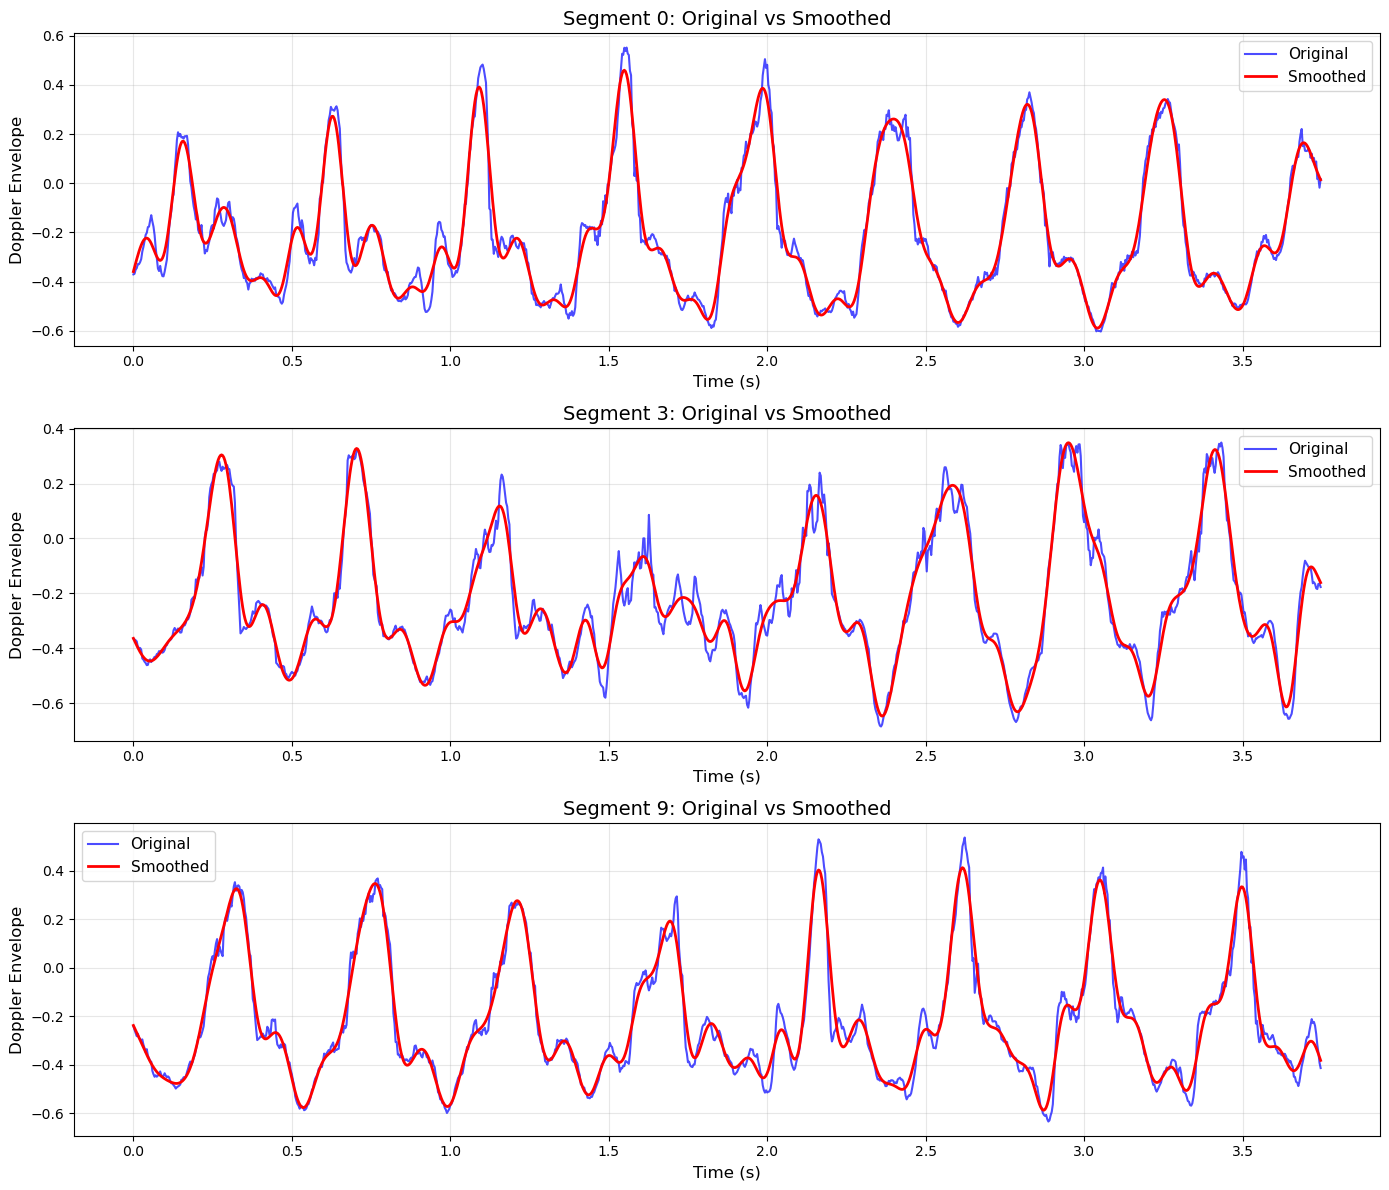

In [19]:
smoothed_single = smooth_all_segments(
        one_ch_generated, 
        fs=284, 
        cutoff_hz=10.0, 
        order=4
    )

visualize_smoothing_comparison(
    one_ch_generated, 
    smoothed_single, 
    segment_indices=[0, 3, 9], 
    fs=284
)

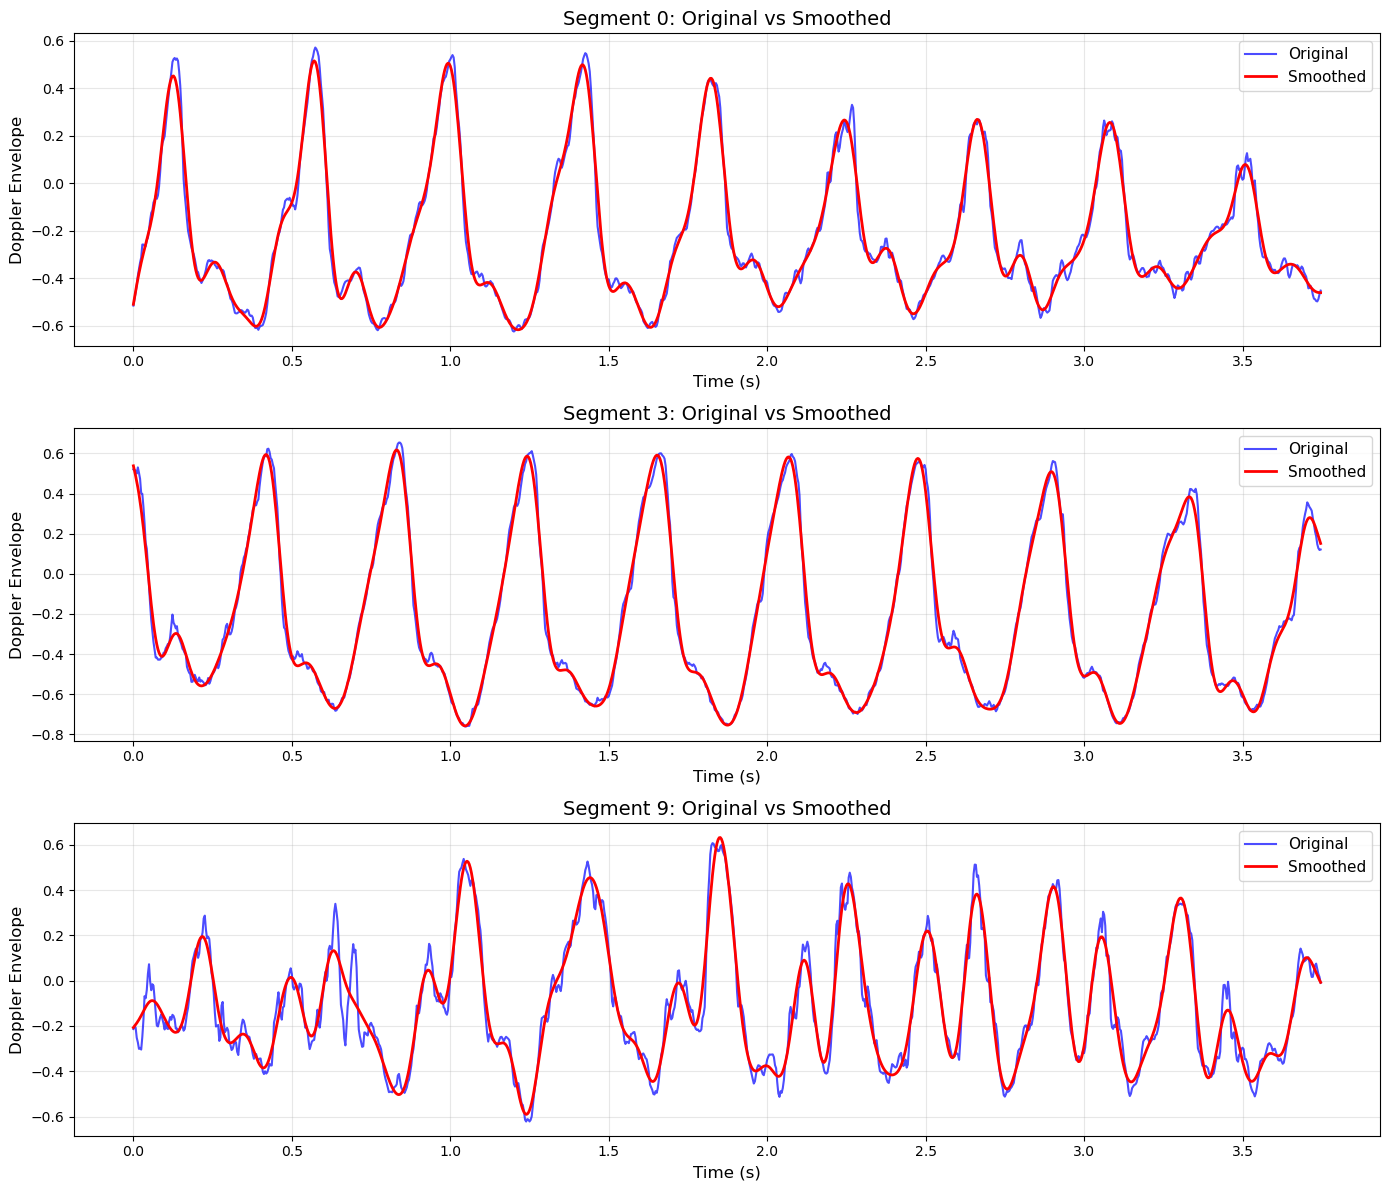

In [7]:
smoothed_fusion = smooth_all_segments(
        two_ch_generated, 
        fs=284, 
        cutoff_hz=10.0, 
        order=4
    )

visualize_smoothing_comparison(
    two_ch_generated, 
    smoothed_fusion, 
    segment_indices=[0, 3, 9], 
    fs=284
)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.spatial.distance import euclidean
from fastdtw import fastdtw

def calculate_mae(y_true, y_pred):
    """Calculate Mean Absolute Error"""
    return np.mean(np.abs(y_true - y_pred))

def calculate_gradient_mae(y_true, y_pred):
    """Calculate MAE on the gradients (temporal derivatives)"""
    grad_true = np.gradient(y_true)
    grad_pred = np.gradient(y_pred)
    return np.mean(np.abs(grad_true - grad_pred))

def calculate_pearson(y_true, y_pred):
    """Calculate Pearson Correlation Coefficient"""
    corr, _ = pearsonr(y_true, y_pred)
    return corr

def calculate_dtw(y_true, y_pred):
    """Calculate Dynamic Time Warping distance"""
    # Reshape for fastdtw (needs 2D arrays)
    y_true_2d = y_true.reshape(-1, 1)
    y_pred_2d = y_pred.reshape(-1, 1)
    distance, _ = fastdtw(y_true_2d, y_pred_2d, dist=euclidean)
    return distance

def compare_doppler_envelopes(ground_truth, predictions, model_name="Model", risk_group=None):
    """
    Compare predicted Doppler envelopes with ground truth.
    
    Parameters:
    -----------
    ground_truth : np.ndarray
        Ground truth Doppler envelopes, shape (n_samples, sequence_length)
    predictions : np.ndarray
        Predicted Doppler envelopes, shape (n_samples, sequence_length)
    model_name : str
        Name of the model for display purposes
    risk_group : str, optional
        Risk group label for display (e.g., 'Low-Risk', 'High-Risk')
    
    Returns:
    --------
    dict : Dictionary containing mean and std of each metric
    """
    n_samples, seq_length = ground_truth.shape
    
    # Initialize lists to store metrics for each segment
    mae_scores = []
    grad_mae_scores = []
    pearson_scores = []
    dtw_scores = []
    
    group_label = f" ({risk_group})" if risk_group else ""
    print(f"Computing metrics for {model_name}{group_label}...")
    print(f"Processing {n_samples} segments of length {seq_length}...\n")
    
    # Calculate metrics for each segment
    for i in range(n_samples):
        y_true = ground_truth[i]
        y_pred = predictions[i]
        
        # MAE
        mae = calculate_mae(y_true, y_pred)
        mae_scores.append(mae)
        
        # Gradient MAE
        grad_mae = calculate_gradient_mae(y_true, y_pred)
        grad_mae_scores.append(grad_mae)
        
        # Pearson Correlation
        pearson = calculate_pearson(y_true, y_pred)
        pearson_scores.append(pearson)
        
        # DTW
        dtw = calculate_dtw(y_true, y_pred)
        dtw_scores.append(dtw)
        
        # Progress indicator
        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{n_samples} segments...")
    
    # Calculate mean and std for each metric
    results = {
        'MAE': {
            'mean': np.mean(mae_scores),
            'std': np.std(mae_scores),
            'all': mae_scores
        },
        'Gradient_MAE': {
            'mean': np.mean(grad_mae_scores),
            'std': np.std(grad_mae_scores),
            'all': grad_mae_scores
        },
        'Pearson_Correlation': {
            'mean': np.mean(pearson_scores),
            'std': np.std(pearson_scores),
            'all': pearson_scores
        },
        'DTW': {
            'mean': np.mean(dtw_scores),
            'std': np.std(dtw_scores),
            'all': dtw_scores
        }
    }
    
    # Print results
    print(f"\n{'='*60}")
    print(f"Results for {model_name}{group_label}")
    print(f"{'='*60}")
    print(f"MAE:                  {results['MAE']['mean']:.6f} ± {results['MAE']['std']:.6f}")
    print(f"Gradient MAE:         {results['Gradient_MAE']['mean']:.6f} ± {results['Gradient_MAE']['std']:.6f}")
    print(f"Pearson Correlation:  {results['Pearson_Correlation']['mean']:.6f} ± {results['Pearson_Correlation']['std']:.6f}")
    print(f"DTW Distance:         {results['DTW']['mean']:.2f} ± {results['DTW']['std']:.2f}")
    print(f"{'='*60}\n")
    
    return results


def compare_by_risk_groups(ground_truth, predictions, risk_groups, val_idx, model_name="Model"):
    """
    Compare model performance across risk groups.
    
    Parameters:
    -----------
    ground_truth : np.ndarray
        Ground truth Doppler envelopes for validation set
    predictions : np.ndarray
        Predicted Doppler envelopes for validation set
    risk_groups : np.ndarray
        Risk group labels for all samples
    val_idx : np.ndarray
        Validation indices
    model_name : str
        Name of the model for display purposes
    
    Returns:
    --------
    dict : Dictionary containing results for each risk group
    """
    # Get risk groups for validation samples
    val_risk_groups = risk_groups[val_idx]
    
    # Separate indices by risk group
    high_risk_mask = val_risk_groups == 'yes'
    low_risk_mask = val_risk_groups == 'no'
    
    print(f"\n{'='*70}")
    print(f"Risk Group Distribution for {model_name}")
    print(f"{'='*70}")
    print(f"High-risk samples: {high_risk_mask.sum()}")
    print(f"Low-risk samples: {low_risk_mask.sum()}")
    print(f"{'='*70}\n")
    
    # Get predictions and ground truth for each group
    high_risk_real = ground_truth[high_risk_mask]
    high_risk_pred = predictions[high_risk_mask]
    
    low_risk_real = ground_truth[low_risk_mask]
    low_risk_pred = predictions[low_risk_mask]
    
    # Calculate metrics for each group
    low_risk_results = compare_doppler_envelopes(
        low_risk_real, low_risk_pred, model_name, risk_group="Low-Risk"
    )
    
    high_risk_results = compare_doppler_envelopes(
        high_risk_real, high_risk_pred, model_name, risk_group="High-Risk"
    )
    
    return {
        'low_risk': low_risk_results,
        'high_risk': high_risk_results
    }


def plot_metric_comparison(results_dict, model_name="Model", save_path=None):
    """
    Create side-by-side box plots comparing metrics between risk groups.
    
    Parameters:
    -----------
    results_dict : dict
        Dictionary with 'low_risk' and 'high_risk' keys containing results
    model_name : str
        Name of the model for plot title
    save_path : str, optional
        Path to save the figure
    """
    metrics = ['MAE', 'Gradient_MAE', 'Pearson_Correlation', 'DTW']
    metric_labels = ['MAE', 'Gradient MAE', 'Pearson Correlation', 'DTW Distance']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[idx]
        
        low_risk_data = results_dict['low_risk'][metric]['all']
        high_risk_data = results_dict['high_risk'][metric]['all']
        
        # Create box plot
        bp = ax.boxplot(
            [low_risk_data, high_risk_data],
            labels=['Low-Risk', 'High-Risk'],
            patch_artist=True,
            showmeans=True,
            meanprops=dict(marker='D', markerfacecolor='red', markersize=8)
        )
        
        # Color the boxes
        bp['boxes'][0].set_facecolor('lightblue')
        bp['boxes'][1].set_facecolor('lightcoral')
        
        # Add mean values as text
        low_mean = results_dict['low_risk'][metric]['mean']
        high_mean = results_dict['high_risk'][metric]['mean']
        low_std = results_dict['low_risk'][metric]['std']
        high_std = results_dict['high_risk'][metric]['std']
        
        ax.text(1, ax.get_ylim()[1] * 0.95, 
                f'μ={low_mean:.4f}\nσ={low_std:.4f}',
                ha='center', va='top', fontsize=9, 
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
        
        ax.text(2, ax.get_ylim()[1] * 0.95, 
                f'μ={high_mean:.4f}\nσ={high_std:.4f}',
                ha='center', va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))
        
        ax.set_ylabel(label, fontsize=11)
        ax.set_title(f'{label} by Risk Group', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f'{model_name}: Performance Comparison by Risk Group', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
    
    plt.show()


def plot_metric_bars(results_dict, model_name="Model", save_path=None):
    """
    Create side-by-side bar plots comparing mean metrics between risk groups.
    
    Parameters:
    -----------
    results_dict : dict
        Dictionary with 'low_risk' and 'high_risk' keys containing results
    model_name : str
        Name of the model for plot title
    save_path : str, optional
        Path to save the figure
    """
    metrics = ['MAE', 'Gradient_MAE', 'Pearson_Correlation', 'DTW']
    metric_labels = ['MAE', 'Gradient MAE', 'Pearson\nCorrelation', 'DTW Distance']
    
    low_means = [results_dict['low_risk'][m]['mean'] for m in metrics]
    high_means = [results_dict['high_risk'][m]['mean'] for m in metrics]
    low_stds = [results_dict['low_risk'][m]['std'] for m in metrics]
    high_stds = [results_dict['high_risk'][m]['std'] for m in metrics]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bars1 = ax.bar(x - width/2, low_means, width, yerr=low_stds, 
                   label='Low-Risk', color='lightblue', capsize=5, alpha=0.8)
    bars2 = ax.bar(x + width/2, high_means, width, yerr=high_stds,
                   label='High-Risk', color='lightcoral', capsize=5, alpha=0.8)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.4f}',
                   ha='center', va='bottom', fontsize=9)
    
    ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
    ax.set_ylabel('Values', fontsize=12, fontweight='bold')
    ax.set_title(f'{model_name}: Mean Metrics Comparison by Risk Group', 
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
    
    plt.show()


# Example usage:
"""
# Calculate metrics by risk group
results = compare_by_risk_groups(
    ground_truth=real_dopplers,
    predictions=two_ch_generated,
    risk_groups=RISK_GROUPS,
    val_idx=val_idx,
    model_name="Two-Channel WaveNet"
)

# Create visualizations
plot_metric_comparison(results, model_name="Two-Channel WaveNet", 
                       save_path="./plots/risk_comparison_boxplot.png")

plot_metric_bars(results, model_name="Two-Channel WaveNet",
                 save_path="./plots/risk_comparison_bars.png")
"""

'\n# Calculate metrics by risk group\nresults = compare_by_risk_groups(\n    ground_truth=real_dopplers,\n    predictions=two_ch_generated,\n    risk_groups=RISK_GROUPS,\n    val_idx=val_idx,\n    model_name="Two-Channel WaveNet"\n)\n\n# Create visualizations\nplot_metric_comparison(results, model_name="Two-Channel WaveNet", \n                       save_path="./plots/risk_comparison_boxplot.png")\n\nplot_metric_bars(results, model_name="Two-Channel WaveNet",\n                 save_path="./plots/risk_comparison_bars.png")\n'


Risk Group Distribution for Two-Channel WaveNet
High-risk samples: 228
Low-risk samples: 52

Computing metrics for Two-Channel WaveNet (Low-Risk)...
Processing 52 segments of length 1065...

Processed 50/52 segments...

Results for Two-Channel WaveNet (Low-Risk)
MAE:                  0.385062 ± 0.106657
Gradient MAE:         0.043218 ± 0.010903
Pearson Correlation:  0.262878 ± 0.488357
DTW Distance:         177.71 ± 61.92

Computing metrics for Two-Channel WaveNet (High-Risk)...
Processing 228 segments of length 1065...

Processed 50/228 segments...
Processed 100/228 segments...
Processed 150/228 segments...
Processed 200/228 segments...

Results for Two-Channel WaveNet (High-Risk)
MAE:                  0.515612 ± 0.147009
Gradient MAE:         0.045080 ± 0.007257
Pearson Correlation:  -0.056721 ± 0.381405
DTW Distance:         191.37 ± 64.93



/tmp/ipykernel_757343/1554160971.py:206: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_757343/1554160971.py:206: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_757343/1554160971.py:206: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_757343/1554160971.py:206: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


FileNotFoundError: [Errno 2] No such file or directory: '/home/tsu25/ECG_PWD/single_channel/src/plots/risk_comparison_boxplot.png'

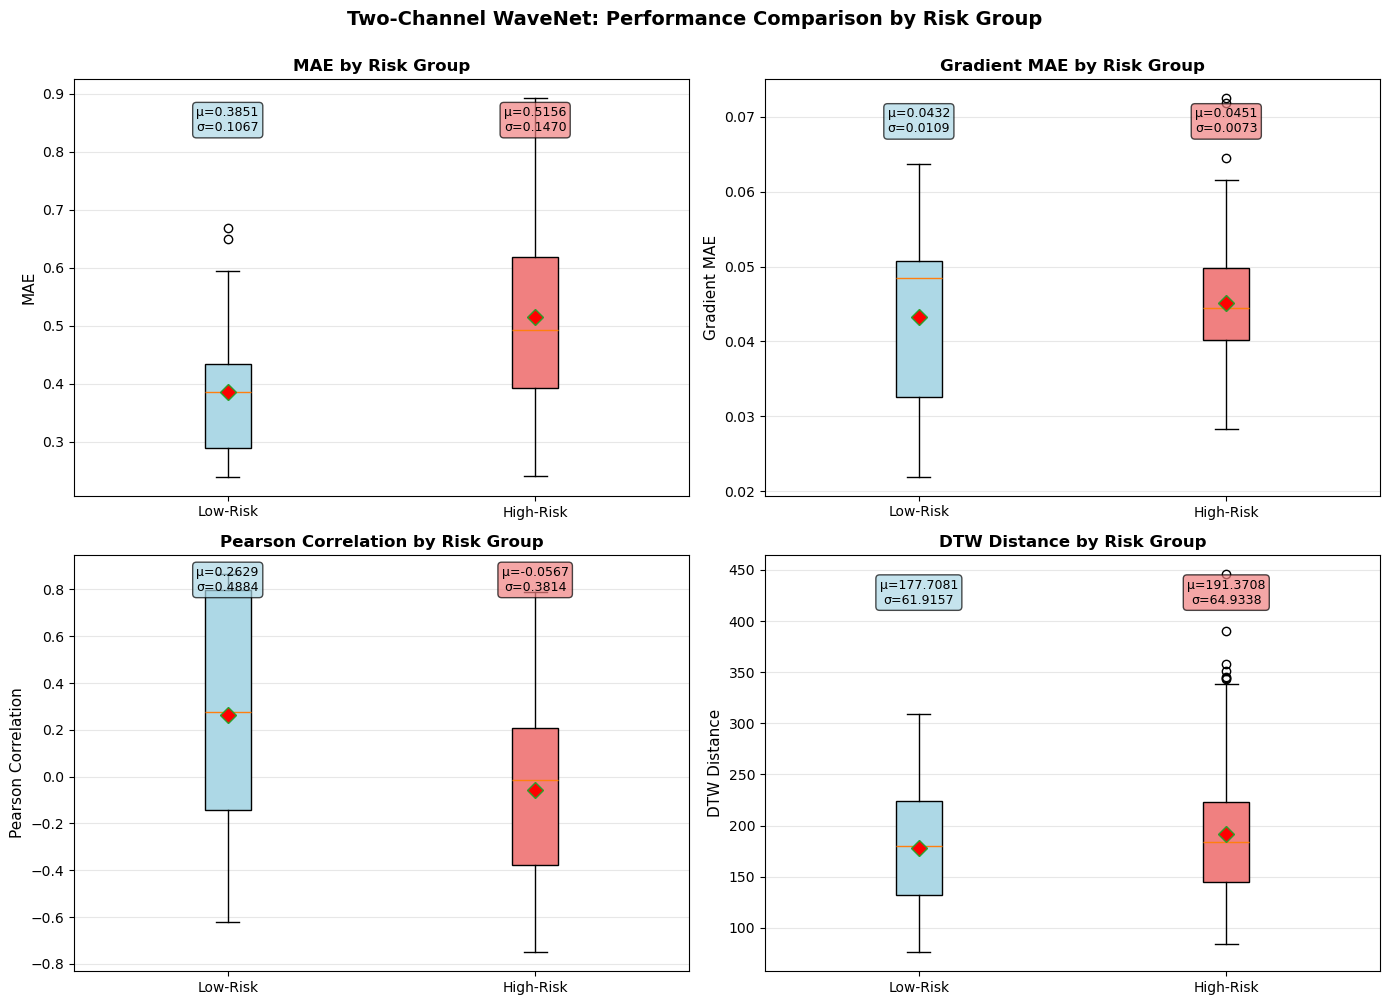

In [9]:
# Calculate metrics separated by risk group
results = compare_by_risk_groups(
    ground_truth=real_dopplers,
    predictions=two_ch_generated,
    risk_groups=RISK_GROUPS,
    val_idx=val_idx,
    model_name="Two-Channel WaveNet"
)

# Create box plot comparison
plot_metric_comparison(results, model_name="Two-Channel WaveNet", 
                       save_path="./plots/risk_comparison_boxplot.png")

# Create bar chart comparison
plot_metric_bars(results, model_name="Two-Channel WaveNet",
                 save_path="./plots/risk_comparison_bars.png")

In [21]:
import numpy as np
from scipy.stats import pearsonr
from scipy.spatial.distance import euclidean
from fastdtw import fastdtw

def calculate_mae(y_true, y_pred):
    """Calculate Mean Absolute Error"""
    return np.mean(np.abs(y_true - y_pred))

def calculate_gradient_mae(y_true, y_pred):
    """Calculate MAE on the gradients (temporal derivatives)"""
    grad_true = np.gradient(y_true)
    grad_pred = np.gradient(y_pred)
    return np.mean(np.abs(grad_true - grad_pred))

def calculate_pearson(y_true, y_pred):
    """Calculate Pearson Correlation Coefficient"""
    corr, _ = pearsonr(y_true, y_pred)
    return corr

def calculate_dtw(y_true, y_pred):
    """Calculate Dynamic Time Warping distance"""
    # Reshape for fastdtw (needs 2D arrays)
    y_true_2d = y_true.reshape(-1, 1)
    y_pred_2d = y_pred.reshape(-1, 1)
    distance, _ = fastdtw(y_true_2d, y_pred_2d, dist=euclidean)
    return distance

def compare_doppler_envelopes(ground_truth, predictions, model_name="Model"):
    """
    Compare predicted Doppler envelopes with ground truth.
    
    Parameters:
    -----------
    ground_truth : np.ndarray
        Ground truth Doppler envelopes, shape (n_samples, sequence_length)
    predictions : np.ndarray
        Predicted Doppler envelopes, shape (n_samples, sequence_length)
    model_name : str
        Name of the model for display purposes
        
    Returns:
    --------
    dict : Dictionary containing mean and std of each metric
    """
    n_samples, seq_length = ground_truth.shape
    
    # Initialize lists to store metrics for each segment
    mae_scores = []
    grad_mae_scores = []
    pearson_scores = []
    dtw_scores = []
    
    print(f"Computing metrics for {model_name}...")
    print(f"Processing {n_samples} segments of length {seq_length}...\n")
    
    # Calculate metrics for each segment
    for i in range(n_samples):
        y_true = ground_truth[i]
        y_pred = predictions[i]
        
        # MAE
        mae = calculate_mae(y_true, y_pred)
        mae_scores.append(mae)
        
        # Gradient MAE
        grad_mae = calculate_gradient_mae(y_true, y_pred)
        grad_mae_scores.append(grad_mae)
        
        # Pearson Correlation
        pearson = calculate_pearson(y_true, y_pred)
        pearson_scores.append(pearson)
        
        # DTW
        dtw = calculate_dtw(y_true, y_pred)
        dtw_scores.append(dtw)
        
        # Progress indicator
        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{n_samples} segments...")
    
    # Calculate mean and std for each metric
    results = {
        'MAE': {
            'mean': np.mean(mae_scores),
            'std': np.std(mae_scores),
            'all': mae_scores
        },
        'Gradient_MAE': {
            'mean': np.mean(grad_mae_scores),
            'std': np.std(grad_mae_scores),
            'all': grad_mae_scores
        },
        'Pearson_Correlation': {
            'mean': np.mean(pearson_scores),
            'std': np.std(pearson_scores),
            'all': pearson_scores
        },
        'DTW': {
            'mean': np.mean(dtw_scores),
            'std': np.std(dtw_scores),
            'all': dtw_scores
        }
    }
    
    # Print results
    print(f"\n{'='*60}")
    print(f"Results for {model_name}")
    print(f"{'='*60}")
    print(f"MAE:                  {results['MAE']['mean']:.6f} ± {results['MAE']['std']:.6f}")
    print(f"Gradient MAE:         {results['Gradient_MAE']['mean']:.6f} ± {results['Gradient_MAE']['std']:.6f}")
    print(f"Pearson Correlation:  {results['Pearson_Correlation']['mean']:.6f} ± {results['Pearson_Correlation']['std']:.6f}")
    print(f"DTW Distance:         {results['DTW']['mean']:.2f} ± {results['DTW']['std']:.2f}")
    print(f"{'='*60}\n")
    
    return results

In [20]:
one_channel = compare_doppler_envelopes(real_dopplers, smoothed_single, model_name="single_channel")

Computing metrics for single_channel...
Processing 192 segments of length 1065...

Processed 50/192 segments...
Processed 100/192 segments...
Processed 150/192 segments...

Results for single_channel
MAE:                  0.436113 ± 0.128693
Gradient MAE:         0.037364 ± 0.006874
Pearson Correlation:  0.221203 ± 0.463837
DTW Distance:         209.80 ± 53.23



In [ ]:
two_channel = compare_doppler_envelopes(real_dopplers, smoothed_fusion, model_name="single_channel")

Computing metrics for single_channel...
Processing 192 segments of length 1065...

Processed 50/192 segments...
Processed 100/192 segments...
Processed 150/192 segments...

Results for single_channel
MAE:                  0.405203 ± 0.112126
Gradient MAE:         0.055470 ± 0.011841
Pearson Correlation:  0.357122 ± 0.445897
DTW Distance:         165.59 ± 48.76



In [22]:
def calculate_cross_correlation(y_true, y_pred):
    """
    Calculate maximum cross-correlation and the lag at which it occurs.
    
    Parameters:
    -----------
    y_true : np.ndarray
        Ground truth signal (1D array)
    y_pred : np.ndarray
        Predicted signal (1D array)
    
    Returns:
    --------
    max_corr : float
        Maximum cross-correlation coefficient (normalized)
    max_lag : int
        Lag at which maximum correlation occurs 
        (negative = pred is ahead, positive = pred is behind)
    """
    # Normalize signals (zero mean, unit variance)
    y_true_norm = (y_true - np.mean(y_true)) / (np.std(y_true) + 1e-8)
    y_pred_norm = (y_pred - np.mean(y_pred)) / (np.std(y_pred) + 1e-8)
    
    # Compute cross-correlation using numpy
    correlation = np.correlate(y_true_norm, y_pred_norm, mode='full')
    
    # Normalize by the length to get correlation coefficient
    correlation = correlation / len(y_true)
    
    # Find the lag with maximum correlation
    lags = np.arange(-len(y_true) + 1, len(y_true))
    max_idx = np.argmax(correlation)
    max_lag = lags[max_idx]
    max_corr = correlation[max_idx]
    
    return max_corr, max_lag


def compare_cross_correlation(ground_truth, predictions, model_name="Model"):
    """
    Calculate cross-correlation metrics for all segments.
    
    Parameters:
    -----------
    ground_truth : np.ndarray
        Ground truth Doppler envelopes, shape (n_samples, sequence_length)
    predictions : np.ndarray
        Predicted Doppler envelopes, shape (n_samples, sequence_length)
    model_name : str
        Name of the model for display purposes
        
    Returns:
    --------
    dict : Dictionary containing mean and std of cross-correlation metrics
    """
    n_samples, seq_length = ground_truth.shape
    
    # Initialize lists to store metrics for each segment
    max_corr_scores = []
    max_lag_scores = []
    
    print(f"Computing cross-correlation metrics for {model_name}...")
    print(f"Processing {n_samples} segments of length {seq_length}...\n")
    
    # Calculate metrics for each segment
    for i in range(n_samples):
        y_true = ground_truth[i]
        y_pred = predictions[i]
        
        # Cross-correlation
        max_corr, max_lag = calculate_cross_correlation(y_true, y_pred)
        max_corr_scores.append(max_corr)
        max_lag_scores.append(max_lag)
        
        # Progress indicator
        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{n_samples} segments...")
    
    # Calculate mean and std
    results = {
        'Max_Cross_Correlation': {
            'mean': np.mean(max_corr_scores),
            'std': np.std(max_corr_scores),
            'all': max_corr_scores
        },
        'Max_Cross_Corr_Lag': {
            'mean': np.mean(max_lag_scores),
            'std': np.std(max_lag_scores),
            'all': max_lag_scores
        }
    }
    
    # Print results
    print(f"\n{'='*60}")
    print(f"Results for {model_name}")
    print(f"{'='*60}")
    print(f"Max Cross-Correlation:  {results['Max_Cross_Correlation']['mean']:.6f} ± {results['Max_Cross_Correlation']['std']:.6f}")
    print(f"Max Cross-Corr Lag:     {results['Max_Cross_Corr_Lag']['mean']:.2f} ± {results['Max_Cross_Corr_Lag']['std']:.2f} time steps")
    print(f"{'='*60}\n")
    
    return results

In [23]:
cross_one = compare_cross_correlation(real_dopplers, smoothed_single, model_name="single_channel")

Computing cross-correlation metrics for single_channel...
Processing 192 segments of length 1065...

Processed 50/192 segments...
Processed 100/192 segments...
Processed 150/192 segments...

Results for single_channel
Max Cross-Correlation:  0.738544 ± 0.131185
Max Cross-Corr Lag:     -11.93 ± 81.70 time steps



In [24]:
cross_two = compare_cross_correlation(real_dopplers, smoothed_fusion, model_name="two_channel")

Computing cross-correlation metrics for two_channel...
Processing 192 segments of length 1065...

Processed 50/192 segments...
Processed 100/192 segments...
Processed 150/192 segments...

Results for two_channel
Max Cross-Correlation:  0.698846 ± 0.143217
Max Cross-Corr Lag:     1.31 ± 101.90 time steps



In [25]:
def plot_cross_correlation_lag_histogram(results_dict, model_names=None, bins=50, 
                                          figsize=(14, 6), save_path=None):
    """
    Plot histogram of cross-correlation lag values for one or more models.
    
    Parameters:
    -----------
    results_dict : dict or list of dict
        Dictionary (or list of dictionaries) containing cross-correlation results
        from compare_cross_correlation function. Each dict should have 
        'Max_Cross_Corr_Lag' key with 'all' subkey containing lag values.
    model_names : list of str, optional
        Names of models corresponding to results_dict. If None and results_dict
        is a single dict, uses "Model". If results_dict is a list, uses 
        "Model 1", "Model 2", etc.
    bins : int or str, default=50
        Number of bins for histogram (or 'auto', 'sturges', etc.)
    figsize : tuple, default=(14, 6)
        Figure size (width, height)
    save_path : str, optional
        Path to save the figure. If None, figure is not saved.
    
    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    """
    import matplotlib.pyplot as plt
    
    # Handle single dict input
    if isinstance(results_dict, dict):
        results_dict = [results_dict]
        if model_names is None:
            model_names = ["Model"]
    
    # Generate default names if not provided
    if model_names is None:
        model_names = [f"Model {i+1}" for i in range(len(results_dict))]
    
    n_models = len(results_dict)
    
    # Create subplots
    if n_models == 1:
        fig, axes = plt.subplots(1, 1, figsize=figsize)
        axes = [axes]
    else:
        fig, axes = plt.subplots(1, n_models, figsize=figsize, sharey=True)
    
    # Plot histogram for each model
    for idx, (results, model_name, ax) in enumerate(zip(results_dict, model_names, axes)):
        lag_values = results['Max_Cross_Corr_Lag']['all']
        mean_lag = results['Max_Cross_Corr_Lag']['mean']
        std_lag = results['Max_Cross_Corr_Lag']['std']
        
        # Plot histogram
        n, bins_edges, patches = ax.hist(lag_values, bins=bins, 
                                          color='steelblue', alpha=0.7, 
                                          edgecolor='black', linewidth=0.5)
        
        # Add vertical line for mean
        ax.axvline(mean_lag, color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_lag:.2f}')
        
        # Add shaded region for ±1 std
        ax.axvspan(mean_lag - std_lag, mean_lag + std_lag, 
                   alpha=0.2, color='red', label=f'±1 SD: {std_lag:.2f}')
        
        # Add vertical line at zero lag
        ax.axvline(0, color='green', linestyle=':', linewidth=2, 
                   label='Zero lag', alpha=0.7)
        
        # Labels and title
        ax.set_xlabel('Lag (time steps)', fontsize=12, fontweight='bold')
        if idx == 0:
            ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
        ax.set_title(f'{model_name}\n(n={len(lag_values)} segments)', 
                     fontsize=13, fontweight='bold')
        ax.legend(loc='upper right', fontsize=10)
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Add statistics text box
        stats_text = f'Mean: {mean_lag:.2f}\nSD: {std_lag:.2f}\nMedian: {np.median(lag_values):.2f}'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    return fig, axes


def plot_cross_correlation_lag_comparison(results_dict, model_names, bins=50,
                                           figsize=(12, 8), save_path=None):
    """
    Plot overlapping histograms comparing lag distributions across multiple models.
    
    Parameters:
    -----------
    results_dict : list of dict
        List of dictionaries containing cross-correlation results from 
        compare_cross_correlation function.
    model_names : list of str
        Names of models corresponding to results_dict.
    bins : int or str, default=50
        Number of bins for histogram
    figsize : tuple, default=(12, 8)
        Figure size (width, height)
    save_path : str, optional
        Path to save the figure. If None, figure is not saved.
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(figsize=figsize)
    
    colors = ['steelblue', 'coral', 'green', 'purple', 'orange']
    
    # Plot overlapping histograms
    for idx, (results, model_name) in enumerate(zip(results_dict, model_names)):
        lag_values = results['Max_Cross_Corr_Lag']['all']
        mean_lag = results['Max_Cross_Corr_Lag']['mean']
        
        color = colors[idx % len(colors)]
        
        # Plot histogram
        ax.hist(lag_values, bins=bins, alpha=0.5, label=model_name,
                color=color, edgecolor='black', linewidth=0.5)
        
        # Add vertical line for mean
        ax.axvline(mean_lag, color=color, linestyle='--', linewidth=2, alpha=0.8)
    
    # Add zero lag line
    ax.axvline(0, color='black', linestyle=':', linewidth=2, 
               label='Zero lag', alpha=0.7)
    
    # Labels and title
    ax.set_xlabel('Lag (time steps)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=13, fontweight='bold')
    ax.set_title('Cross-Correlation Lag Distribution Comparison', 
                 fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    return fig, ax

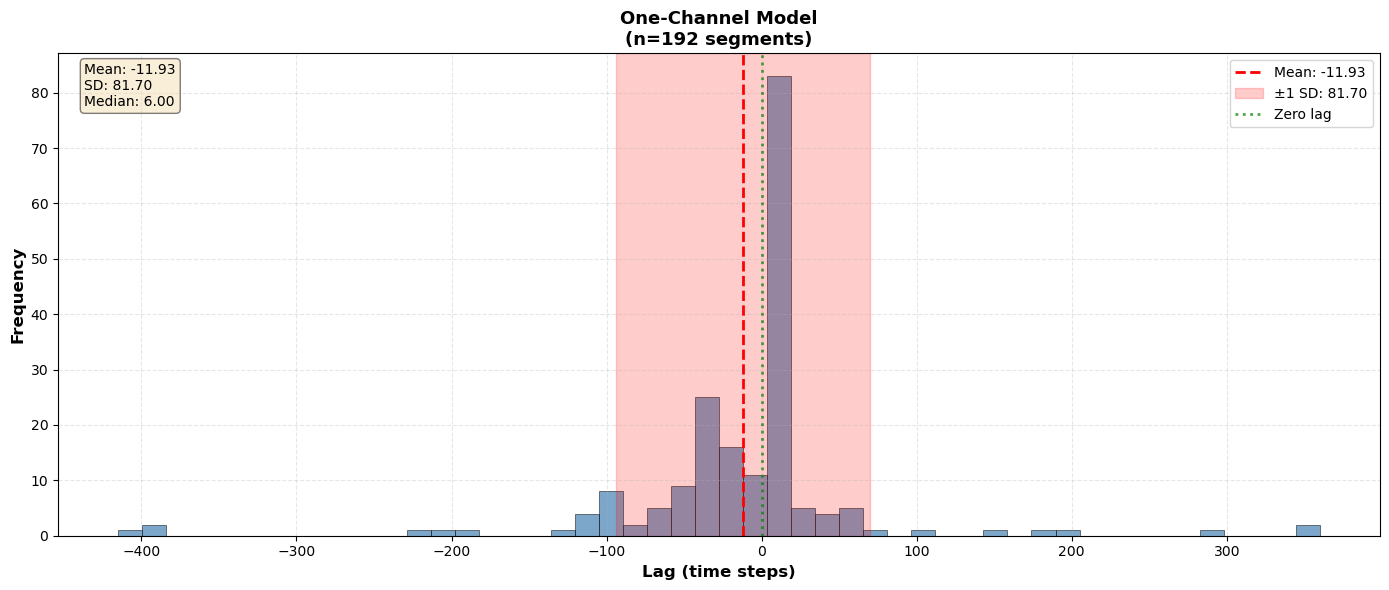

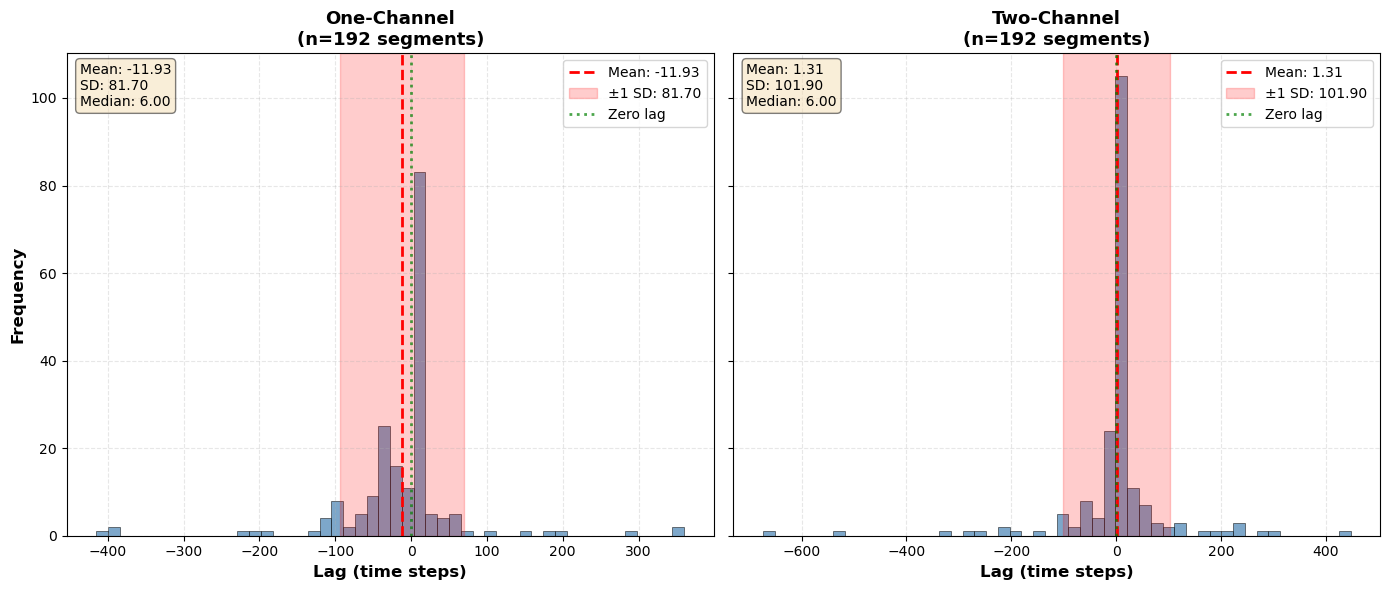

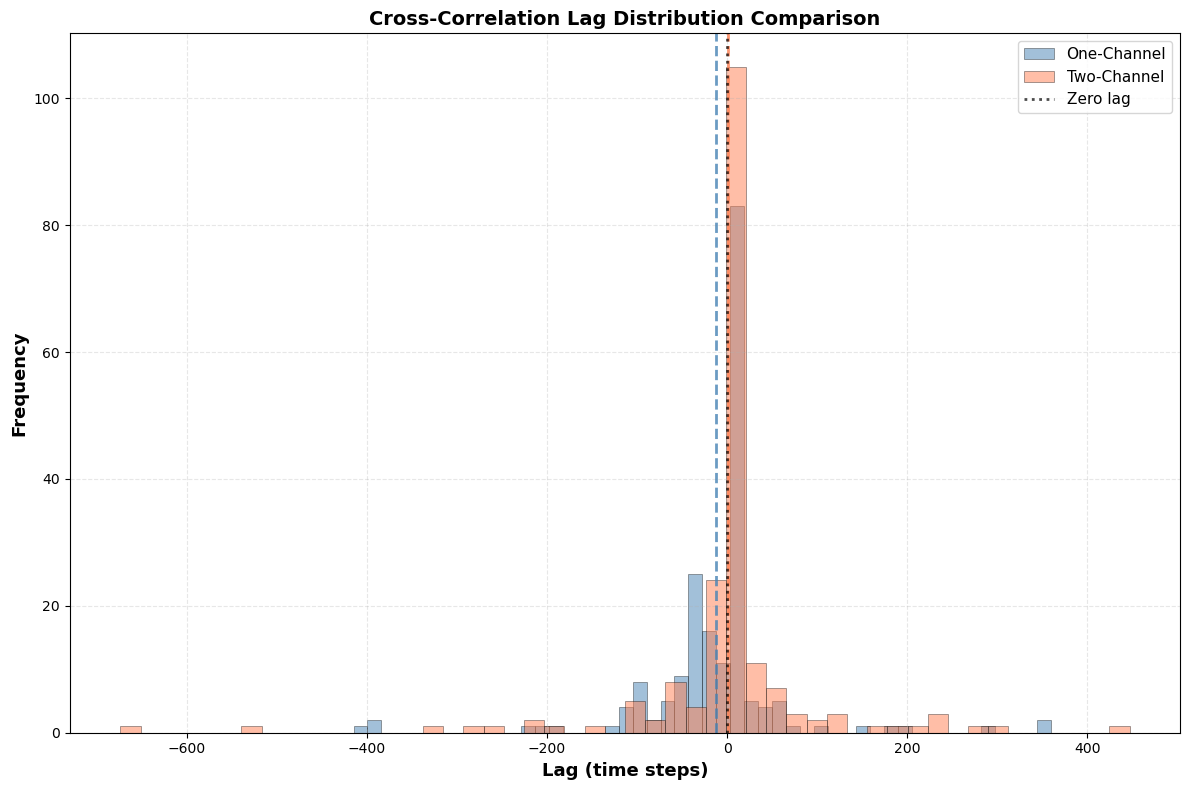

In [26]:
# For a single model:
fig, ax = plot_cross_correlation_lag_histogram(cross_one, model_names=["One-Channel Model"])
plt.show()

# For multiple models side-by-side:
fig, axes = plot_cross_correlation_lag_histogram([cross_one, cross_two], 
                                                   model_names=["One-Channel", "Two-Channel"])
plt.show()

# For overlapping comparison:
fig, ax = plot_cross_correlation_lag_comparison([cross_one, cross_two],
                                                 model_names=["One-Channel", "Two-Channel"])
plt.show()

In [12]:
def calculate_cross_correlation_zero_lag(y_true, y_pred):
    """
    Calculate cross-correlation at lag zero (no temporal shift).
    
    Parameters:
    -----------
    y_true : np.ndarray
        Ground truth signal (1D array)
    y_pred : np.ndarray
        Predicted signal (1D array)
    
    Returns:
    --------
    corr_zero_lag : float
        Cross-correlation coefficient at lag zero (normalized)
    """
    # Normalize signals (zero mean, unit variance)
    y_true_norm = (y_true - np.mean(y_true)) / (np.std(y_true) + 1e-8)
    y_pred_norm = (y_pred - np.mean(y_pred)) / (np.std(y_pred) + 1e-8)
    
    # Calculate correlation at zero lag (element-wise multiplication and sum)
    corr_zero_lag = np.sum(y_true_norm * y_pred_norm) / len(y_true)
    
    return corr_zero_lag


def compare_cross_correlation_zero(ground_truth, predictions, model_name="Model"):
    """
    Calculate cross-correlation at zero lag for all segments.
    
    Parameters:
    -----------
    ground_truth : np.ndarray
        Ground truth Doppler envelopes, shape (n_samples, sequence_length)
    predictions : np.ndarray
        Predicted Doppler envelopes, shape (n_samples, sequence_length)
    model_name : str
        Name of the model for display purposes
    
    Returns:
    --------
    dict : Dictionary containing mean and std of cross-correlation at zero lag
    """
    n_samples, seq_length = ground_truth.shape
    
    # Initialize list to store metrics for each segment
    corr_scores = []
    
    print(f"Computing cross-correlation at zero lag for {model_name}...")
    print(f"Processing {n_samples} segments of length {seq_length}...\n")
    
    # Calculate metrics for each segment
    for i in range(n_samples):
        y_true = ground_truth[i]
        y_pred = predictions[i]
        
        # Cross-correlation at zero lag
        corr = calculate_cross_correlation_zero_lag(y_true, y_pred)
        corr_scores.append(corr)
        
        # Progress indicator
        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{n_samples} segments...")
    
    # Calculate mean and std
    results = {
        'Cross_Correlation_Zero_Lag': {
            'mean': np.mean(corr_scores),
            'std': np.std(corr_scores),
            'all': corr_scores
        }
    }
    
    # Print results
    print(f"\n{'='*60}")
    print(f"Results for {model_name}")
    print(f"{'='*60}")
    print(f"Cross-Correlation (lag=0): {results['Cross_Correlation_Zero_Lag']['mean']:.6f} ± {results['Cross_Correlation_Zero_Lag']['std']:.6f}")
    print(f"{'='*60}\n")
    
    return results

In [13]:
zero_cross_two = compare_cross_correlation_zero(real_dopplers, smoothed_fusion, model_name="two_channel")

Computing cross-correlation at zero lag for two_channel...
Processing 192 segments of length 1065...

Processed 50/192 segments...
Processed 100/192 segments...
Processed 150/192 segments...

Results for two_channel
Cross-Correlation (lag=0): 0.366147 ± 0.465823



In [14]:
zero_cross_one = compare_cross_correlation_zero(real_dopplers, smoothed_single, model_name="one_channel")

Computing cross-correlation at zero lag for one_channel...
Processing 192 segments of length 1065...

Processed 50/192 segments...
Processed 100/192 segments...
Processed 150/192 segments...

Results for one_channel
Cross-Correlation (lag=0): 0.221203 ± 0.463837



In [24]:
import numpy as np
from scipy import signal
from scipy.stats import entropy

def calculate_kld(y_true, y_pred, bins=50):
    """
    Calculate Kullback-Leibler Divergence between value distributions.
    
    Parameters:
    -----------
    y_true : np.ndarray
        Ground truth signal (1D array)
    y_pred : np.ndarray
        Predicted signal (1D array)
    bins : int
        Number of bins for histogram
    
    Returns:
    --------
    kld : float
        KL Divergence (lower is better, 0 = identical distributions)
    """
    # Create histograms with the same bins for both signals
    # Use the combined range to ensure same bin edges
    combined_min = min(y_true.min(), y_pred.min())
    combined_max = max(y_true.max(), y_pred.max())
    bin_edges = np.linspace(combined_min, combined_max, bins + 1)
    
    # Compute histograms
    hist_true, _ = np.histogram(y_true, bins=bin_edges, density=True)
    hist_pred, _ = np.histogram(y_pred, bins=bin_edges, density=True)
    
    # Normalize to get probability distributions
    hist_true = hist_true / (hist_true.sum() + 1e-10)
    hist_pred = hist_pred / (hist_pred.sum() + 1e-10)
    
    # Add small epsilon to avoid log(0)
    hist_true = hist_true + 1e-10
    hist_pred = hist_pred + 1e-10
    
    # Calculate KL divergence: KL(P||Q) = sum(P * log(P/Q))
    kld = entropy(hist_true, hist_pred)
    
    return kld


def calculate_psd_similarity(y_true, y_pred, fs=1.0, nperseg=256):
    """
    Calculate Power Spectral Density similarity between signals.
    
    Parameters:
    -----------
    y_true : np.ndarray
        Ground truth signal (1D array)
    y_pred : np.ndarray
        Predicted signal (1D array)
    fs : float
        Sampling frequency (default: 1.0)
    nperseg : int
        Length of each segment for Welch's method
    
    Returns:
    --------
    psd_mse : float
        Mean Squared Error between PSDs (lower is better)
    psd_corr : float
        Correlation between PSDs (higher is better, 0-1)
    """
    # Calculate Power Spectral Density using Welch's method
    freqs_true, psd_true = signal.welch(y_true, fs=fs, nperseg=min(nperseg, len(y_true)))
    freqs_pred, psd_pred = signal.welch(y_pred, fs=fs, nperseg=min(nperseg, len(y_pred)))
    
    # Convert to dB scale for better comparison
    psd_true_db = 10 * np.log10(psd_true + 1e-10)
    psd_pred_db = 10 * np.log10(psd_pred + 1e-10)
    
    # Calculate MSE between PSDs
    psd_mse = np.mean((psd_true_db - psd_pred_db) ** 2)
    
    # Calculate correlation between PSDs
    psd_corr = np.corrcoef(psd_true_db, psd_pred_db)[0, 1]
    
    return psd_mse, psd_corr


def compare_kld_psd(ground_truth, predictions, model_name="Model", fs=1.0, bins=50, nperseg=256):
    """
    Calculate KLD and PSD metrics for all segments.
    
    Parameters:
    -----------
    ground_truth : np.ndarray
        Ground truth Doppler envelopes, shape (n_samples, sequence_length)
    predictions : np.ndarray
        Predicted Doppler envelopes, shape (n_samples, sequence_length)
    model_name : str
        Name of the model for display purposes
    fs : float
        Sampling frequency for PSD calculation
    bins : int
        Number of bins for KLD histogram
    nperseg : int
        Segment length for PSD calculation
        
    Returns:
    --------
    dict : Dictionary containing mean and std of metrics
    """
    n_samples, seq_length = ground_truth.shape
    
    # Initialize lists to store metrics for each segment
    kld_scores = []
    psd_mse_scores = []
    psd_corr_scores = []
    
    print(f"Computing KLD and PSD metrics for {model_name}...")
    print(f"Processing {n_samples} segments of length {seq_length}...\n")
    
    # Calculate metrics for each segment
    for i in range(n_samples):
        y_true = ground_truth[i]
        y_pred = predictions[i]
        
        # KL Divergence
        kld = calculate_kld(y_true, y_pred, bins=bins)
        kld_scores.append(kld)
        
        # PSD metrics
        psd_mse, psd_corr = calculate_psd_similarity(y_true, y_pred, fs=fs, nperseg=nperseg)
        psd_mse_scores.append(psd_mse)
        psd_corr_scores.append(psd_corr)
        
        # Progress indicator
        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{n_samples} segments...")
    
    # Calculate mean and std
    results = {
        'KLD': {
            'mean': np.mean(kld_scores),
            'std': np.std(kld_scores),
            'all': kld_scores
        },
        'PSD_MSE': {
            'mean': np.mean(psd_mse_scores),
            'std': np.std(psd_mse_scores),
            'all': psd_mse_scores
        },
        'PSD_Correlation': {
            'mean': np.mean(psd_corr_scores),
            'std': np.std(psd_corr_scores),
            'all': psd_corr_scores
        }
    }
    
    # Print results
    print(f"\n{'='*60}")
    print(f"Results for {model_name}")
    print(f"{'='*60}")
    print(f"KL Divergence:        {results['KLD']['mean']:.6f} ± {results['KLD']['std']:.6f}")
    print(f"PSD MSE (dB²):        {results['PSD_MSE']['mean']:.4f} ± {results['PSD_MSE']['std']:.4f}")
    print(f"PSD Correlation:      {results['PSD_Correlation']['mean']:.6f} ± {results['PSD_Correlation']['std']:.6f}")
    print(f"{'='*60}\n")
    
    return results

In [25]:
_ = compare_kld_psd(real_dopplers, smoothed_single, model_name="one_channel", fs=284, bins=50, nperseg=256)

Computing KLD and PSD metrics for one_channel...
Processing 192 segments of length 1065...

Processed 50/192 segments...
Processed 100/192 segments...
Processed 150/192 segments...

Results for one_channel
KL Divergence:        6.442368 ± 2.580794
PSD MSE (dB²):        30.4151 ± 9.9514
PSD Correlation:      0.982914 ± 0.006450



In [26]:
_ = compare_kld_psd(real_dopplers, smoothed_fusion, model_name="two_channel", fs=284, bins=50, nperseg=256)

Computing KLD and PSD metrics for two_channel...
Processing 192 segments of length 1065...

Processed 50/192 segments...
Processed 100/192 segments...
Processed 150/192 segments...

Results for two_channel
KL Divergence:        3.990019 ± 2.117896
PSD MSE (dB²):        19.5560 ± 8.2874
PSD Correlation:      0.988336 ± 0.005221



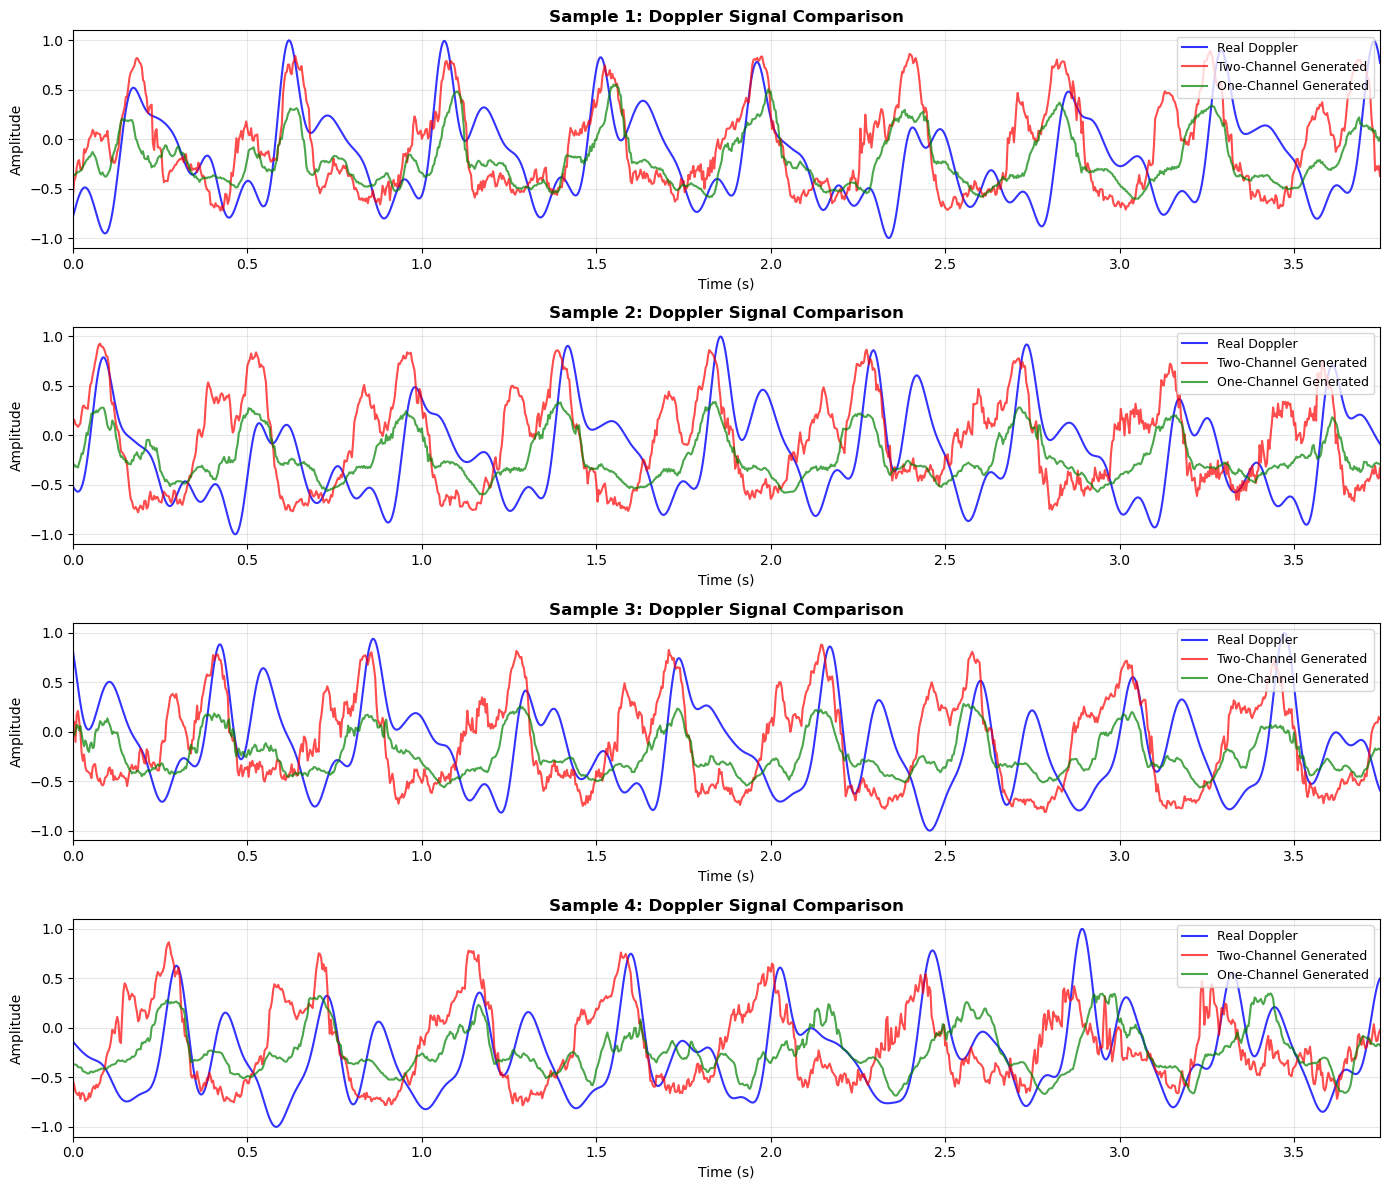

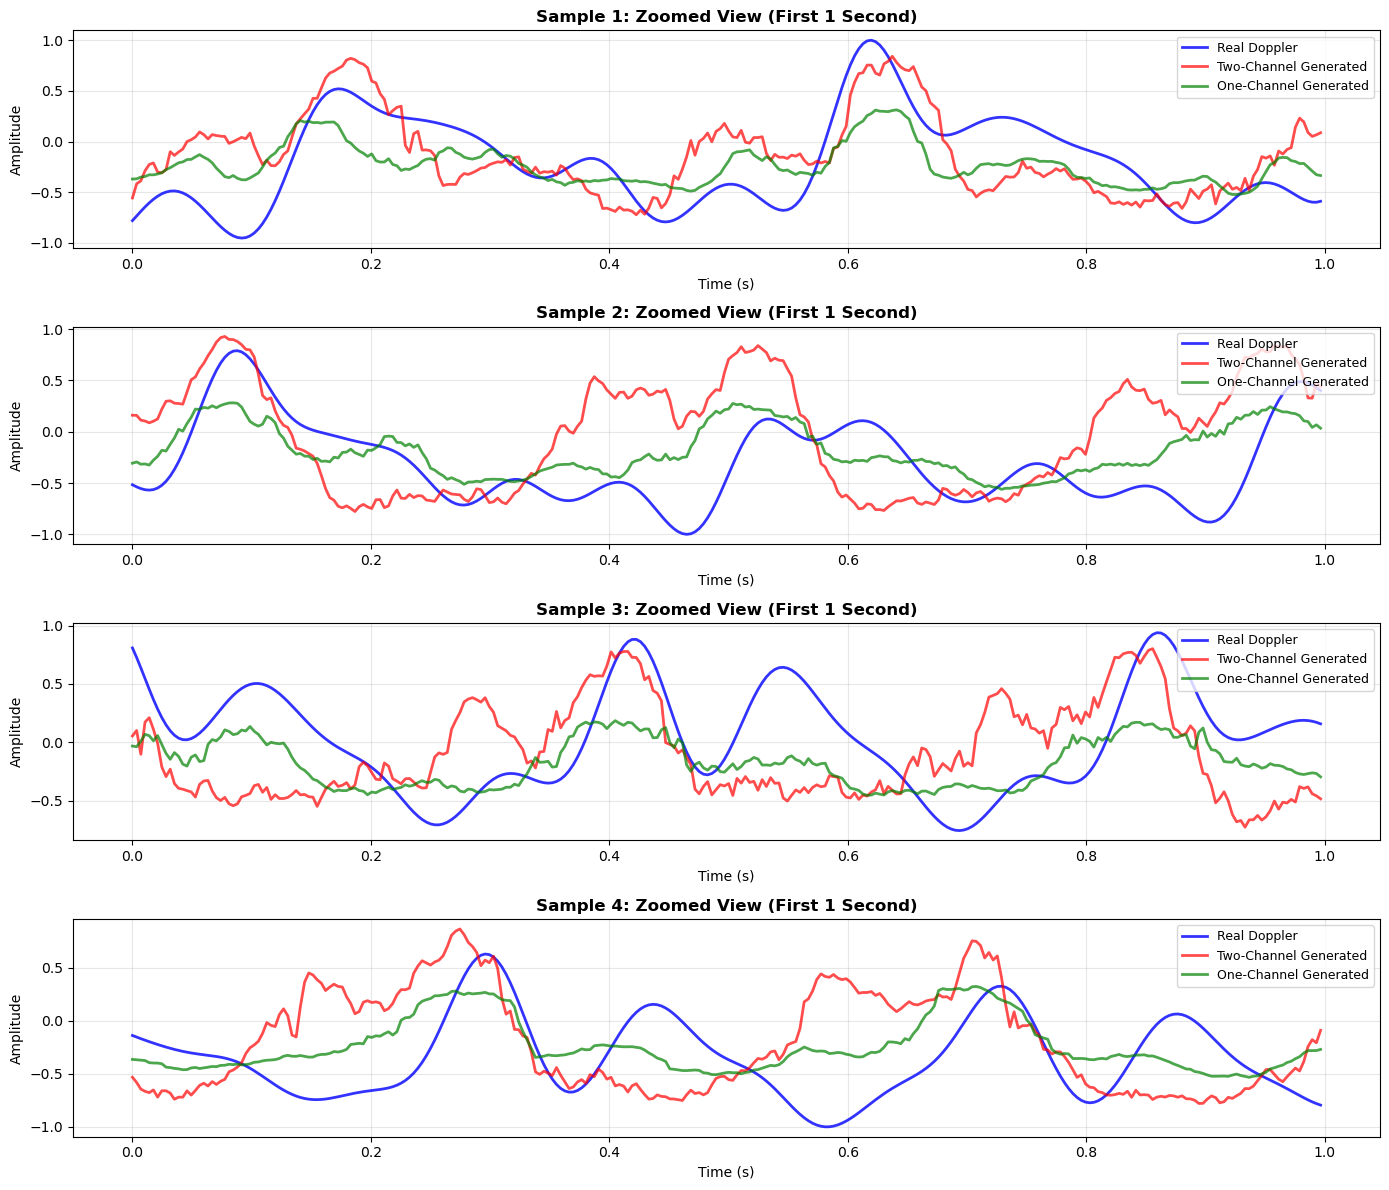

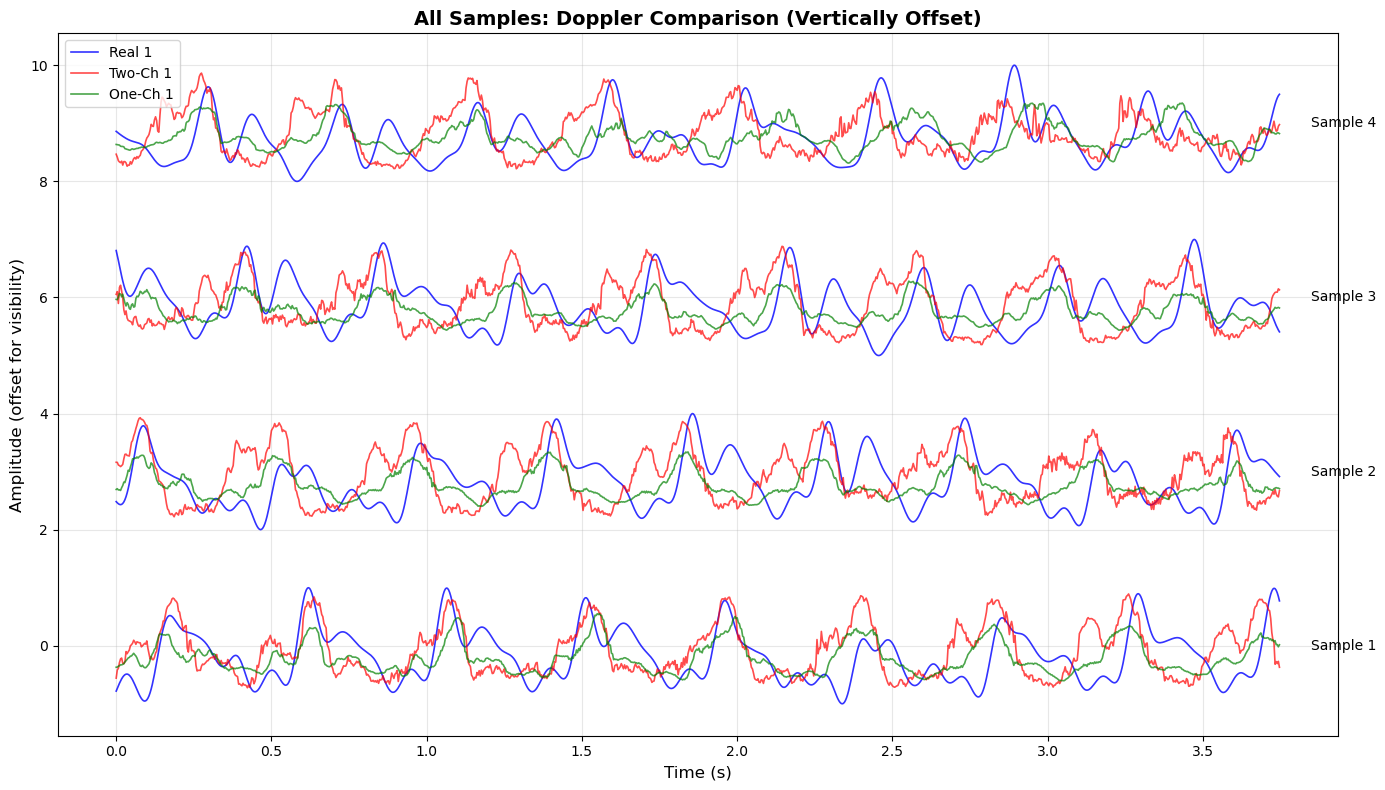

QUANTITATIVE COMPARISON METRICS

Sample 1:
  Two-Channel Model:
    Correlation: 0.3206 (p=6.89e-27)
    MSE: 0.277994
    MAE: 0.438426
  One-Channel Model:
    Correlation: 0.4820 (p=4.68e-63)
    MSE: 0.159071
    MAE: 0.333478
  ✓ One-Channel model performs better (higher correlation)

Sample 2:
  Two-Channel Model:
    Correlation: 0.0333 (p=2.78e-01)
    MSE: 0.415238
    MAE: 0.556731
  One-Channel Model:
    Correlation: 0.4102 (p=1.78e-44)
    MSE: 0.171845
    MAE: 0.357139
  ✓ One-Channel model performs better (higher correlation)

Sample 3:
  Two-Channel Model:
    Correlation: 0.0631 (p=3.95e-02)
    MSE: 0.366852
    MAE: 0.524880
  One-Channel Model:
    Correlation: 0.5019 (p=5.00e-69)
    MSE: 0.149571
    MAE: 0.331039
  ✓ One-Channel model performs better (higher correlation)

Sample 4:
  Two-Channel Model:
    Correlation: 0.1978 (p=7.41e-11)
    MSE: 0.261013
    MAE: 0.415236
  One-Channel Model:
    Correlation: 0.4943 (p=1.04e-66)
    MSE: 0.125369
    MAE: 0.28

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set sampling frequency (adjust to your data)
fs = 284  # Hz
num_samples = 4

# Create figure with subplots
fig, axes = plt.subplots(num_samples, 1, figsize=(14, 3*num_samples))

# two_ch_generated = smoothed_fusion
# one_ch_generated = smoothed_single

two_ch_generated = np.load('/home/tsu25/ECG_PWD/Fetal-maternal-fusion/src/WaveNet_beat/generated_data/final_two_ch_model_generated_dopplers.npy')
one_ch_generated = np.load('/home/tsu25/ECG_PWD/single_channel/src/WaveNet_beat/generated_data/final_one_ch_model_generated_dopplers.npy')


# Plot each sample
for i in range(num_samples):
    # Create time axis
    time = np.arange(len(real_dopplers[i])) / fs
    
    # Plot all three signals
    axes[i].plot(time, real_dopplers[i], 'b-', linewidth=1.5, 
                 label='Real Doppler', alpha=0.8)
    axes[i].plot(time, two_ch_generated[i], 'r-', linewidth=1.5, 
                 label='Two-Channel Generated', alpha=0.7)
    axes[i].plot(time, one_ch_generated[i], 'g-', linewidth=1.5, 
                 label='One-Channel Generated', alpha=0.7)
    
    # Formatting
    axes[i].set_title(f'Sample {i+1}: Doppler Signal Comparison', 
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Time (s)', fontsize=10)
    axes[i].set_ylabel('Amplitude', fontsize=10)
    axes[i].legend(loc='upper right', fontsize=9)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim([time[0], time[-1]])

plt.tight_layout()
plt.savefig('doppler_comparison_all.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a zoomed-in comparison for better detail
fig2, axes2 = plt.subplots(num_samples, 1, figsize=(14, 3*num_samples))

if num_samples == 1:
    axes2 = [axes2]

# Show only first 1 second for detailed view
zoom_samples = int(1.0 * fs)  # 1 second

for i in range(num_samples):
    # Create time axis for zoomed view
    time_zoom = np.arange(min(zoom_samples, len(real_dopplers[i]))) / fs
    zoom_len = len(time_zoom)
    
    # Plot zoomed signals
    axes2[i].plot(time_zoom, real_dopplers[i][:zoom_len], 'b-', 
                  linewidth=2, label='Real Doppler', alpha=0.8)
    axes2[i].plot(time_zoom, two_ch_generated[i][:zoom_len], 'r-', 
                  linewidth=2, label='Two-Channel Generated', alpha=0.7)
    axes2[i].plot(time_zoom, one_ch_generated[i][:zoom_len], 'g-', 
                  linewidth=2, label='One-Channel Generated', alpha=0.7)
    
    # Formatting
    axes2[i].set_title(f'Sample {i+1}: Zoomed View (First 1 Second)', 
                       fontsize=12, fontweight='bold')
    axes2[i].set_xlabel('Time (s)', fontsize=10)
    axes2[i].set_ylabel('Amplitude', fontsize=10)
    axes2[i].legend(loc='upper right', fontsize=9)
    axes2[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('doppler_comparison_zoomed.png', dpi=300, bbox_inches='tight')
plt.show()

# Create overlay comparison with offset for clarity
fig3, ax = plt.subplots(figsize=(14, 8))

# Offset factor for visual separation
offset = 3.0

for i in range(num_samples):
    time = np.arange(len(real_dopplers[i])) / fs
    vertical_offset = i * offset
    
    # Plot with vertical offset
    ax.plot(time, real_dopplers[i] + vertical_offset, 'b-', 
            linewidth=1.2, label=f'Real {i+1}' if i == 0 else '', alpha=0.8)
    ax.plot(time, two_ch_generated[i] + vertical_offset, 'r-', 
            linewidth=1.2, label=f'Two-Ch {i+1}' if i == 0 else '', alpha=0.7)
    ax.plot(time, one_ch_generated[i] + vertical_offset, 'g-', 
            linewidth=1.2, label=f'One-Ch {i+1}' if i == 0 else '', alpha=0.7)
    
    # Add sample label
    ax.text(time[-1] + 0.1, vertical_offset, f'Sample {i+1}', 
            fontsize=10, verticalalignment='center')

ax.set_title('All Samples: Doppler Comparison (Vertically Offset)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Amplitude (offset for visibility)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('doppler_comparison_stacked.png', dpi=300, bbox_inches='tight')
plt.show()

# Compute and display quantitative metrics
print("=" * 70)
print("QUANTITATIVE COMPARISON METRICS")
print("=" * 70)

from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error

for i in range(num_samples):
    print(f"\nSample {i+1}:")
    
    # Correlation with real
    corr_two_ch, p_two = pearsonr(real_dopplers[i], two_ch_generated[i])
    corr_one_ch, p_one = pearsonr(real_dopplers[i], one_ch_generated[i])
    
    # MSE and MAE
    mse_two_ch = mean_squared_error(real_dopplers[i], two_ch_generated[i])
    mse_one_ch = mean_squared_error(real_dopplers[i], one_ch_generated[i])
    
    mae_two_ch = mean_absolute_error(real_dopplers[i], two_ch_generated[i])
    mae_one_ch = mean_absolute_error(real_dopplers[i], one_ch_generated[i])
    
    print(f"  Two-Channel Model:")
    print(f"    Correlation: {corr_two_ch:.4f} (p={p_two:.2e})")
    print(f"    MSE: {mse_two_ch:.6f}")
    print(f"    MAE: {mae_two_ch:.6f}")
    
    print(f"  One-Channel Model:")
    print(f"    Correlation: {corr_one_ch:.4f} (p={p_one:.2e})")
    print(f"    MSE: {mse_one_ch:.6f}")
    print(f"    MAE: {mae_one_ch:.6f}")
    
    # Determine better model
    if corr_two_ch > corr_one_ch:
        print(f"  ✓ Two-Channel model performs better (higher correlation)")
    else:
        print(f"  ✓ One-Channel model performs better (higher correlation)")

print("\n" + "=" * 70)
print("Plots saved:")
print("  - doppler_comparison_all.png (full signals)")
print("  - doppler_comparison_zoomed.png (first 1 second detail)")
print("  - doppler_comparison_stacked.png (all samples stacked)")
print("=" * 70)


Computing Power Spectral Density...


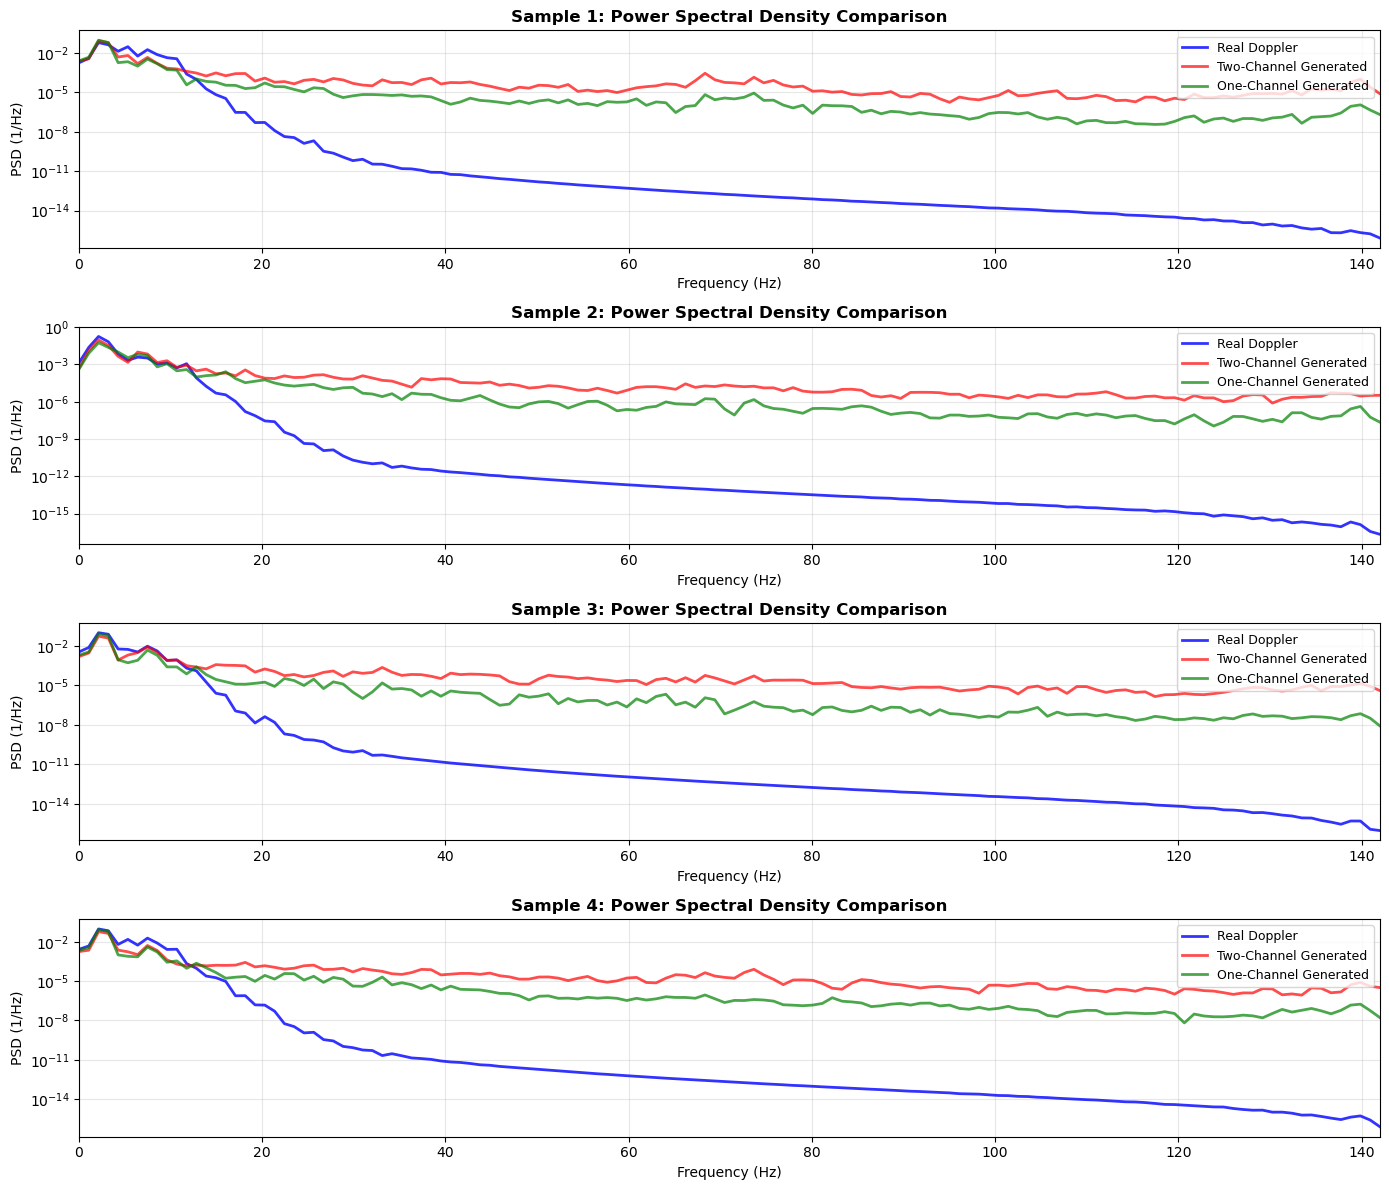

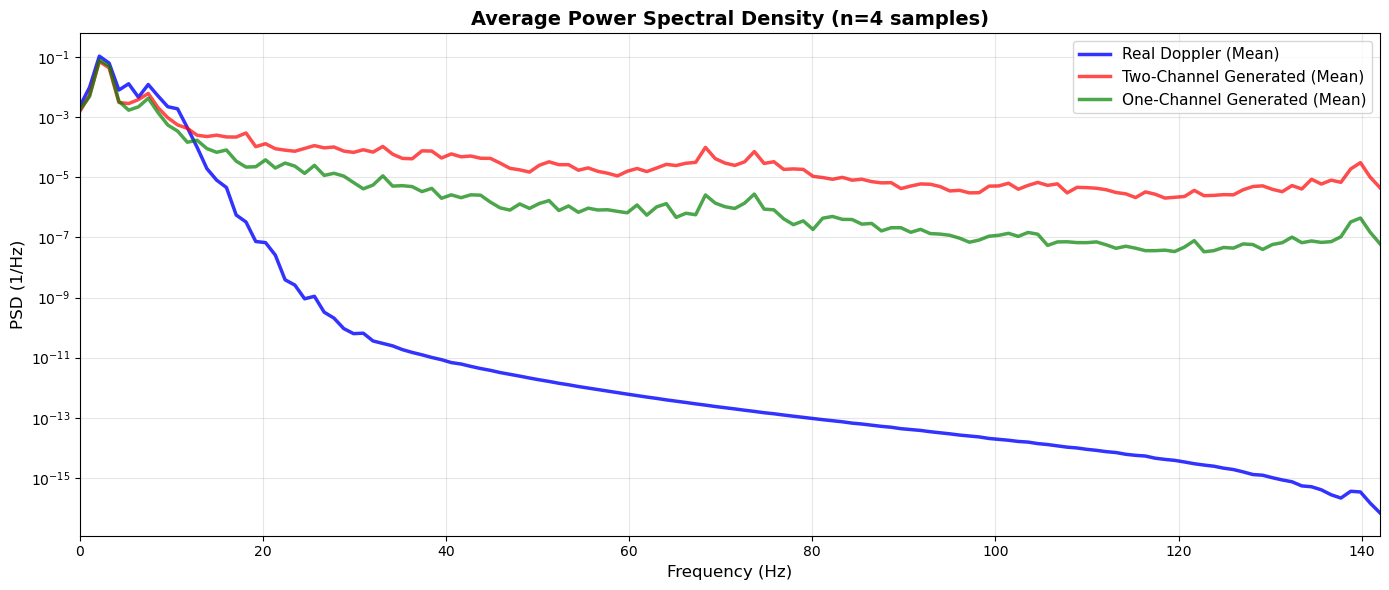


PSD-BASED METRICS

Sample 1:
  Total Power:
    Real: 1.9740e-01
    Two-Channel: 1.8186e-01 (ratio: 0.921)
    One-Channel: 1.7871e-01 (ratio: 0.905)
  Peak Frequency:
    Real: 2.14 Hz
    Two-Channel: 2.14 Hz (diff: 0.00 Hz)
    One-Channel: 2.14 Hz (diff: 0.00 Hz)
  PSD Correlation:
    Two-Channel: 0.9225
    One-Channel: 0.9026
  Spectral Distance (RMSE):
    Two-Channel: 3.511377e-03
    One-Channel: 4.274548e-03
  ✓ Two-Channel has better spectral similarity

Sample 2:
  Total Power:
    Real: 3.0360e-01
    Two-Channel: 1.8003e-01 (ratio: 0.593)
    One-Channel: 1.2121e-01 (ratio: 0.399)
  Peak Frequency:
    Real: 2.14 Hz
    Two-Channel: 2.14 Hz (diff: 0.00 Hz)
    One-Channel: 2.14 Hz (diff: 0.00 Hz)
  PSD Correlation:
    Two-Channel: 0.9952
    One-Channel: 0.9843
  Spectral Distance (RMSE):
    Two-Channel: 7.847548e-03
    One-Channel: 1.112149e-02
  ✓ Two-Channel has better spectral similarity

Sample 3:
  Total Power:
    Real: 2.2992e-01
    Two-Channel: 1.2931e-01 

In [19]:
# Compute and plot PSD for all signals
from scipy import signal as sp_signal

print("\nComputing Power Spectral Density...")

# PSD comparison for each sample
fig4, axes4 = plt.subplots(num_samples, 1, figsize=(14, 3*num_samples))

if num_samples == 1:
    axes4 = [axes4]

for i in range(num_samples):
    # Compute PSD using Welch's method
    nperseg = min(4096, len(real_dopplers[i])//4)
    
    freqs_real, psd_real = sp_signal.welch(real_dopplers[i], fs=fs, nperseg=nperseg)
    freqs_two, psd_two = sp_signal.welch(two_ch_generated[i], fs=fs, nperseg=nperseg)
    freqs_one, psd_one = sp_signal.welch(one_ch_generated[i], fs=fs, nperseg=nperseg)
    
    # Plot PSD
    axes4[i].semilogy(freqs_real, psd_real, 'b-', linewidth=2, 
                      label='Real Doppler', alpha=0.8)
    axes4[i].semilogy(freqs_two, psd_two, 'r-', linewidth=2, 
                      label='Two-Channel Generated', alpha=0.7)
    axes4[i].semilogy(freqs_one, psd_one, 'g-', linewidth=2, 
                      label='One-Channel Generated', alpha=0.7)
    
    # Formatting
    axes4[i].set_title(f'Sample {i+1}: Power Spectral Density Comparison', 
                       fontsize=12, fontweight='bold')
    axes4[i].set_xlabel('Frequency (Hz)', fontsize=10)
    axes4[i].set_ylabel('PSD (1/Hz)', fontsize=10)
    axes4[i].legend(loc='upper right', fontsize=9)
    axes4[i].grid(True, alpha=0.3)
    axes4[i].set_xlim([0, fs/2])

plt.tight_layout()
plt.savefig('doppler_psd_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Create averaged PSD across all samples
fig5, ax5 = plt.subplots(figsize=(14, 6))

# Compute average PSD across all samples
psd_real_all = []
psd_two_all = []
psd_one_all = []

for i in range(num_samples):
    nperseg = min(4096, len(real_dopplers[i])//4)
    freqs, psd_real = sp_signal.welch(real_dopplers[i], fs=fs, nperseg=nperseg)
    _, psd_two = sp_signal.welch(two_ch_generated[i], fs=fs, nperseg=nperseg)
    _, psd_one = sp_signal.welch(one_ch_generated[i], fs=fs, nperseg=nperseg)
    
    psd_real_all.append(psd_real)
    psd_two_all.append(psd_two)
    psd_one_all.append(psd_one)

# Average PSDs
psd_real_mean = np.mean(psd_real_all, axis=0)
psd_two_mean = np.mean(psd_two_all, axis=0)
psd_one_mean = np.mean(psd_one_all, axis=0)

# Plot averaged PSD
ax5.semilogy(freqs, psd_real_mean, 'b-', linewidth=2.5, 
             label='Real Doppler (Mean)', alpha=0.8)
ax5.semilogy(freqs, psd_two_mean, 'r-', linewidth=2.5, 
             label='Two-Channel Generated (Mean)', alpha=0.7)
ax5.semilogy(freqs, psd_one_mean, 'g-', linewidth=2.5, 
             label='One-Channel Generated (Mean)', alpha=0.7)

ax5.set_title(f'Average Power Spectral Density (n={num_samples} samples)', 
              fontsize=14, fontweight='bold')
ax5.set_xlabel('Frequency (Hz)', fontsize=12)
ax5.set_ylabel('PSD (1/Hz)', fontsize=12)
ax5.legend(loc='upper right', fontsize=11)
ax5.grid(True, alpha=0.3)
ax5.set_xlim([0, fs/2])

plt.tight_layout()
plt.savefig('doppler_psd_averaged.png', dpi=300, bbox_inches='tight')
plt.show()

# Compute PSD-based metrics
print("\n" + "=" * 70)
print("PSD-BASED METRICS")
print("=" * 70)

for i in range(num_samples):
    nperseg = min(4096, len(real_dopplers[i])//4)
    freqs, psd_real = sp_signal.welch(real_dopplers[i], fs=fs, nperseg=nperseg)
    _, psd_two = sp_signal.welch(two_ch_generated[i], fs=fs, nperseg=nperseg)
    _, psd_one = sp_signal.welch(one_ch_generated[i], fs=fs, nperseg=nperseg)
    
    # Total power
    power_real = np.trapz(psd_real, freqs)
    power_two = np.trapz(psd_two, freqs)
    power_one = np.trapz(psd_one, freqs)
    
    # Peak frequency
    peak_freq_real = freqs[np.argmax(psd_real)]
    peak_freq_two = freqs[np.argmax(psd_two)]
    peak_freq_one = freqs[np.argmax(psd_one)]
    
    # PSD correlation
    corr_psd_two = pearsonr(psd_real, psd_two)[0]
    corr_psd_one = pearsonr(psd_real, psd_one)[0]
    
    # Spectral distance (normalized L2 norm)
    spectral_dist_two = np.sqrt(np.mean((psd_real - psd_two)**2))
    spectral_dist_one = np.sqrt(np.mean((psd_real - psd_one)**2))
    
    print(f"\nSample {i+1}:")
    print(f"  Total Power:")
    print(f"    Real: {power_real:.4e}")
    print(f"    Two-Channel: {power_two:.4e} (ratio: {power_two/power_real:.3f})")
    print(f"    One-Channel: {power_one:.4e} (ratio: {power_one/power_real:.3f})")
    
    print(f"  Peak Frequency:")
    print(f"    Real: {peak_freq_real:.2f} Hz")
    print(f"    Two-Channel: {peak_freq_two:.2f} Hz (diff: {abs(peak_freq_two-peak_freq_real):.2f} Hz)")
    print(f"    One-Channel: {peak_freq_one:.2f} Hz (diff: {abs(peak_freq_one-peak_freq_real):.2f} Hz)")
    
    print(f"  PSD Correlation:")
    print(f"    Two-Channel: {corr_psd_two:.4f}")
    print(f"    One-Channel: {corr_psd_one:.4f}")
    
    print(f"  Spectral Distance (RMSE):")
    print(f"    Two-Channel: {spectral_dist_two:.6e}")
    print(f"    One-Channel: {spectral_dist_one:.6e}")
    
    # Determine better spectral match
    if corr_psd_two > corr_psd_one:
        print(f"  ✓ Two-Channel has better spectral similarity")
    else:
        print(f"  ✓ One-Channel has better spectral similarity")

print("\n" + "=" * 70)
print("Plots saved:")
print("  - doppler_comparison_all.png (full signals)")
print("  - doppler_comparison_zoomed.png (first 1 second detail)")
print("  - doppler_comparison_stacked.png (all samples stacked)")
print("  - doppler_psd_comparison.png (PSD for each sample)")
print("  - doppler_psd_averaged.png (averaged PSD across samples)")
print("=" * 70)

In [13]:
# Calculate metrics
rmse = calculate_rmse(generated_dopplers, DUS_array_test)
mae = calculate_mae(generated_dopplers, DUS_array_test)
kld = calculate_kld(generated_dopplers, DUS_array_test)
dtw_distance = calculate_dtw(generated_dopplers, DUS_array_test)
correlation = calculate_correlation(generated_dopplers, DUS_array_test)
sdtw = calculate_soft_dtw(generated_dopplers, DUS_array_test)
ed = calculate_euclidean_distance(generated_dopplers, DUS_array_test)
rdd = calculate_rdd(generated_dopplers, DUS_array_test)
prd = calculate_prd(generated_dopplers, DUS_array_test)
entropy = calculate_spectral_entropy(generated_dopplers, DUS_array_test)
psd = calculate_psd_difference(generated_dopplers, DUS_array_test)
centroid = calculate_spectral_centroid_difference(generated_dopplers, DUS_array_test)
flatness = calculate_flatness_difference(generated_dopplers, DUS_array_test)
fd = calculate_discrete_frechet_distance(generated_dopplers, DUS_array_test)

# Print results
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"KLD: {kld}")
print(f"DTW Distance: {dtw_distance}")
print(f"Correlation: {correlation}")
print(f"Soft DTW: {sdtw}")
print(f"ED: {ed}")
print(f"RDD: {rdd}")
print(f"prd: {prd}")
print(f"spectral entropy: {entropy}")
print(f"psd difference: {psd}")
print(f"centroid difference: {centroid}")
print(f"spectral flatness: {flatness}")
print(f"fd: {fd}")

RMSE: 0.33695852756500244
MAE: 0.2486354410648346
KLD: 0.029695459219484934
DTW Distance: 1829.429809965528
Correlation: 0.7482076481207383
Soft DTW: 21403.052734375
ED: 146.29779052734375
RDD: 4882.955508474576
prd: 64.26037549972534
spectral entropy: 0.07596206665039062
psd difference: 0.01714416593313217
centroid difference: 10.58498275916264
spectral flatness: 0.024074668064713478
fd: 6.982143878936768


In [10]:
import pandas as pd

metrics = [
    ("RMSE",               0.3981609642505646,  "Moderate point-wise error (≈ 20 % scale)"),
    ("MAE",                0.30351194739341736, "Typical absolute deviation per sample"),
    ("KLD",                0.1525541972389974,  "Amplitude distribution close; small divergence"),
    ("DTW",                2270.005806179246,   "Avg. mis-alignment ≈ 2 samples (warped)"),
    ("Pearson r",          0.5534738365210246,  "Medium linear similarity"),
    ("Soft-DTW",           29884.1015625,       "Residual timing/shape mismatch remains"),
    ("Euclidean dist.",    172.8701629638672,   "Cumulative point-wise error energy"),
    ("RDD",                9.590573044429379e9, "Scale-sensitive; inflated by small denom."),
    ("PRD",                75.98966360092163,   "Error energy still high; noticeable distortion"),
    ("Spectral entropy Δ", 0.7945833206176758,  "Generated PSD flatter (peaks lost)"),
    ("PSD ℓ2 Δ",           0.033398982137441635,"Overall spectra fairly close"),
    ("Centroid Δ",         24.94859342651444,   "Energy shifted higher; less low-freq content"),
    ("Flatness Δ",         0.31084978580474854, "Generated envelopes noisier / less tonal"),
    ("Fréchet dist.",      10.08528995513916,   "Global shape drift remains")
]

df_metrics = pd.DataFrame(metrics, columns=["Metric", "Value", "Interpretation"])
df_metrics["Value"] = df_metrics["Value"].map("{:.6f}".format)

In [11]:
df_metrics

,Metric,Value,Interpretation
0,RMSE,0.398161,Moderate point-wise error (≈ 20 % scale)
1,MAE,0.303512,Typical absolute deviation per sample
2,KLD,0.152554,Amplitude distribution close; small divergence
3,DTW,2270.005806,Avg. mis-alignment ≈ 2 samples (warped)
4,Pearson r,0.553474,Medium linear similarity
5,Soft-DTW,29884.101562,Residual timing/shape mismatch remains
6,Euclidean dist.,172.870163,Cumulative point-wise error energy
7,RDD,9590573044.429379,Scale-sensitive; inflated by small denom.
8,PRD,75.989664,Error energy still high; noticeable distortion
9,Spectral entropy Δ,0.794583,Generated PSD flatter (peaks lost)
